# 07 — Khulna Paper-Style ML Downscaling (FINAL FIXED v2)

This version is linked to the corrected **00–06D** workflow.

### Critical fixes included
- Uses `station_samples_native_tidy_REPAIRED.csv` from Notebook 06D.
- Uses logical feature name `GSMaP_Gauge` (actual raw folder was `GSMaP_Gauge_v7`).
- `Comb1` = 8 precipitation products.
- `Comb2` = CHIRPS + PERSIANN-CDR (`CDR`) + ERA5.
- Land set = DEM + NDVI + LST Day + Distance to Sea.
- Train = 2017–2020, validation = 2021, independent test = 2022.
- Hyperparameters are selected **only from validation performance**.
- After hyperparameter selection, the model is refit on train + validation and evaluated once on 2022.
- No global imputation.
- No edge clamping.
- Spatial prediction uses a **combination-specific valid mask**.
- Coverage is calculated **inside the Khulna study mask**, not over the full rectangular raster.
- Annual rainfall is summed only where **all 12 monthly predictions are valid**.
- A valid-month-count raster is also saved for QC.
- Outputs are not artificially clipped to a preferred rainfall range; only physically impossible negative predictions are clipped to 0.
- `0.005°` is treated as output grid spacing, not guaranteed independent rainfall information resolution.

The default spatial output is generated for the **best validation-selected model for each combination** to reduce storage. Set `GENERATE_ALL_EXPERIMENT_MAPS = True` if you later want maps for every model × combination.


In [1]:
# ============================================================
# 1. PROJECT SETUP
# ============================================================

from pathlib import Path
import json
import math
import warnings
import joblib

import numpy as np
import pandas as pd
import rasterio

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import ParameterGrid

def find_project_root(start=None):
    current = Path(start or Path.cwd()).resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists():
            return candidate

    raise FileNotFoundError(
        "Project root not found. Run this notebook from inside the repository."
    )

PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
MODEL_DIR = PROJECT_ROOT / "models"

RUN_DIR = OUTPUT_DIR / "paper_style_FINAL_v2"
MODEL_OUT = MODEL_DIR / "paper_style_FINAL_v2"

RUN_DIR.mkdir(parents=True, exist_ok=True)
MODEL_OUT.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("RUN_DIR      =", RUN_DIR)


PROJECT_ROOT = E:\Geospatial\Precipitation-Downscaling-Khulna\Machine-Learning-Based-Precipitation-Downscaling-over-Khulna-District-Bangladesh
RUN_DIR      = E:\Geospatial\Precipitation-Downscaling-Khulna\Machine-Learning-Based-Precipitation-Downscaling-over-Khulna-District-Bangladesh\outputs\paper_style_FINAL_v2


In [2]:
# ============================================================
# 2. DATA / FEATURE SETTINGS
# ============================================================

TRAIN_YEARS = [2017, 2018, 2019, 2020]
VALID_YEARS = [2021]
TEST_YEARS = [2022]

PRECIP8 = [
    "CCS",
    "PDIR",
    "GSMaP_MVK",
    "CDR",
    "CHIRPS",
    "IMERG",
    "GSMaP_Gauge",
    "ERA5",
]

LAND = [
    "DEM",
    "NDVI",
    "LST_Day",
    "Distance_Sea",
]

COMBINATIONS = {
    "Comb1": PRECIP8,
    "Comb1_land": PRECIP8 + LAND,
    "Comb2": ["CHIRPS", "CDR", "ERA5"],
    "Comb2_land": ["CHIRPS", "CDR", "ERA5"] + LAND,
}

SAMPLES_PATH = (
    PROCESSED_DIR
    / "station_samples_native_tidy_REPAIRED.csv"
)

GRID_ROOT = (
    PROCESSED_DIR
    / "test2022_target_grid"
)

if not SAMPLES_PATH.exists():
    raise FileNotFoundError(
        "Repaired station table not found. "
        "Run 06D_Local_Pixel_Hole_Repair_FIXED.ipynb first."
    )

if not GRID_ROOT.exists():
    raise FileNotFoundError(
        "2022 target-grid folder not found. "
        "Run 05_TestYear_Target_Grid_Alignment_FIXED_v2.ipynb first."
    )

data = pd.read_csv(SAMPLES_PATH)

required = (
    ["station_id", "year", "month", "rainfall_mm", "latitude", "longitude"]
    + sorted(set(sum(COMBINATIONS.values(), [])))
)

missing_columns = [
    c for c in required
    if c not in data.columns
]

if missing_columns:
    raise KeyError(
        f"Required columns are missing: {missing_columns}"
    )

print("Station table:", data.shape)
print("Stations:", data["station_id"].nunique())
print("Years:", sorted(data["year"].unique()))

# Storage control
GENERATE_ALL_EXPERIMENT_MAPS = False

RANDOM_STATE = 42
OVERWRITE = True


Station table: (432, 19)
Stations: 6
Years: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]


In [3]:
# ============================================================
# 3. MODEL LIBRARIES + PARAMETER GRIDS
# ============================================================

model_builders = {
    "RandomForest": lambda p: RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **p
    )
}

param_grids = {
    "RandomForest": {
        "n_estimators": [300, 600],
        "max_depth": [None, 10, 20],
        "min_samples_leaf": [1, 2],
        "max_features": ["sqrt", 0.8],
    }
}

try:
    from xgboost import XGBRegressor

    model_builders["XGBoost"] = lambda p: XGBRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        objective="reg:squarederror",
        eval_metric="rmse",
        **p
    )

    param_grids["XGBoost"] = {
        "n_estimators": [300, 600],
        "max_depth": [3, 6],
        "learning_rate": [0.03, 0.08],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8],
    }

except Exception as e:
    print("XGBoost unavailable:", e)

try:
    from lightgbm import LGBMRegressor

    model_builders["LightGBM"] = lambda p: LGBMRegressor(
        random_state=RANDOM_STATE,
        verbosity=-1,
        **p
    )

    param_grids["LightGBM"] = {
        "n_estimators": [300, 600],
        "learning_rate": [0.03, 0.08],
        "num_leaves": [15, 31],
        "max_depth": [-1, 10],
    }

except Exception as e:
    print("LightGBM unavailable:", e)

try:
    from catboost import CatBoostRegressor

    model_builders["CatBoost"] = lambda p: CatBoostRegressor(
        random_seed=RANDOM_STATE,
        verbose=False,
        **p
    )

    param_grids["CatBoost"] = {
        "iterations": [300, 600],
        "depth": [4, 6, 8],
        "learning_rate": [0.03, 0.08],
    }

except Exception as e:
    print("CatBoost unavailable:", e)

print("Available models:", list(model_builders))

if not model_builders:
    raise RuntimeError("No regression model is available.")


Available models: ['RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']


In [4]:
# ============================================================
# 4. METRICS / SPLIT HELPERS
# ============================================================

def pcc(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if len(y_true) < 2:
        return np.nan

    if (
        np.std(y_true) == 0
        or np.std(y_pred) == 0
    ):
        return np.nan

    return float(
        np.corrcoef(
            y_true,
            y_pred
        )[0, 1]
    )

def metrics(y_true, y_pred):
    return {
        "MAE": float(
            mean_absolute_error(
                y_true,
                y_pred
            )
        ),
        "RMSE": float(
            np.sqrt(
                mean_squared_error(
                    y_true,
                    y_pred
                )
            )
        ),
        "PCC": pcc(
            y_true,
            y_pred
        ),
        "R2": float(
            r2_score(
                y_true,
                y_pred
            )
        ),
    }

def complete_split(df, years, features):
    d = (
        df[
            df["year"].isin(years)
        ]
        .dropna(
            subset=["rainfall_mm"] + features
        )
        .copy()
    )

    X = d[features].to_numpy(
        dtype=float
    )

    y = d["rainfall_mm"].to_numpy(
        dtype=float
    )

    return d, X, y

# Readiness before modelling
readiness_rows = []

for combo, features in COMBINATIONS.items():
    for split_name, years in {
        "train": TRAIN_YEARS,
        "validation": VALID_YEARS,
        "test": TEST_YEARS,
    }.items():

        d, _, _ = complete_split(
            data,
            years,
            features
        )

        total = int(
            data["year"].isin(years).sum()
        )

        readiness_rows.append({
            "combination": combo,
            "split": split_name,
            "total_rows": total,
            "complete_rows": len(d),
            "complete_pct": (
                100.0 * len(d) / total
                if total else np.nan
            ),
            "stations_remaining": d["station_id"].nunique(),
        })

readiness = pd.DataFrame(readiness_rows)
display(readiness)

readiness.to_csv(
    RUN_DIR / "01_model_readiness.csv",
    index=False
)


,combination,split,total_rows,complete_rows,complete_pct,stations_remaining
0,Comb1,train,288,276,95.833333,6
1,Comb1,validation,72,69,95.833333,6
2,Comb1,test,72,69,95.833333,6
3,Comb1_land,train,288,262,90.972222,6
4,Comb1_land,validation,72,63,87.500000,6
5,Comb1_land,test,72,64,88.888889,6
6,Comb2,train,288,288,100.000000,6
7,Comb2,validation,72,72,100.000000,6
8,Comb2,test,72,72,100.000000,6
9,Comb2_land,train,288,273,94.791667,6


In [5]:
# ============================================================
# 5. HYPERPARAMETER SEARCH ON VALIDATION ONLY
# ============================================================

search_rows = []
validation_models = {}

for combo, features in COMBINATIONS.items():

    tr, Xtr, ytr = complete_split(
        data,
        TRAIN_YEARS,
        features
    )

    va, Xva, yva = complete_split(
        data,
        VALID_YEARS,
        features
    )

    print(
        f"\n=== {combo} === "
        f"train={len(tr)}, validation={len(va)}"
    )

    if len(tr) < 20 or len(va) < 10:
        raise ValueError(
            f"{combo}: insufficient complete rows."
        )

    for model_name, builder in model_builders.items():

        best = None

        for params in ParameterGrid(
            param_grids[model_name]
        ):

            model = builder(
                params
            )

            model.fit(
                Xtr,
                ytr
            )

            pred_val = np.clip(
                model.predict(Xva),
                0,
                None
            )

            vm = metrics(
                yva,
                pred_val
            )

            candidate = {
                "model": model,
                "params": params,
                "valid_metrics": vm,
            }

            # Primary selection = lowest validation RMSE.
            # PCC and MAE are still reported.
            if (
                best is None
                or vm["RMSE"] < best["valid_metrics"]["RMSE"]
            ):
                best = candidate

        validation_models[
            (combo, model_name)
        ] = best["model"]

        row = {
            "combination": combo,
            "model": model_name,
            "n_train": len(tr),
            "n_valid": len(va),
            "valid_MAE": best["valid_metrics"]["MAE"],
            "valid_RMSE": best["valid_metrics"]["RMSE"],
            "valid_PCC": best["valid_metrics"]["PCC"],
            "valid_R2": best["valid_metrics"]["R2"],
            "best_params": json.dumps(
                best["params"]
            ),
        }

        search_rows.append(
            row
        )

validation_results = pd.DataFrame(
    search_rows
).sort_values(
    ["combination", "valid_RMSE"]
).reset_index(
    drop=True
)

print("\nVALIDATION RESULTS")
display(validation_results)

validation_results.to_csv(
    RUN_DIR / "02_validation_model_search.csv",
    index=False
)



=== Comb1 === train=276, validation=69

=== Comb1_land === train=262, validation=63

=== Comb2 === train=288, validation=72

=== Comb2_land === train=273, validation=65

VALIDATION RESULTS


,combination,model,n_train,n_valid,valid_MAE,valid_RMSE,valid_PCC,valid_R2,best_params
0,Comb1,XGBoost,276,69,66.063022,90.296959,0.832020,0.529390,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0..."
1,Comb1,CatBoost,276,69,75.974216,102.500389,0.818981,0.393591,"{""depth"": 8, ""iterations"": 300, ""learning_rate..."
2,Comb1,RandomForest,276,69,76.319838,103.610179,0.808652,0.380389,"{""max_depth"": null, ""max_features"": 0.8, ""min_..."
3,Comb1,LightGBM,276,69,81.019584,112.363005,0.829336,0.271279,"{""learning_rate"": 0.08, ""max_depth"": 10, ""n_es..."
4,Comb1_land,CatBoost,262,63,56.643425,79.281401,0.864850,0.489032,"{""depth"": 8, ""iterations"": 300, ""learning_rate..."
5,Comb1_land,XGBoost,262,63,59.636387,84.215931,0.844240,0.423447,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0..."
6,Comb1_land,RandomForest,262,63,68.843853,94.456996,0.839137,0.274698,"{""max_depth"": 10, ""max_features"": 0.8, ""min_sa..."
7,Comb1_land,LightGBM,262,63,67.219072,101.245691,0.898934,0.166695,"{""learning_rate"": 0.08, ""max_depth"": -1, ""n_es..."
8,Comb2,XGBoost,288,72,72.184781,109.821095,0.800939,0.341255,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0..."
9,Comb2,RandomForest,288,72,75.894526,110.083668,0.783905,0.338101,"{""max_depth"": 10, ""max_features"": 0.8, ""min_sa..."


In [6]:
# ============================================================
# 6. REFIT TRAIN + VALIDATION, THEN TEST ON 2022 ONCE
# ============================================================

test_rows = []
final_models = {}

for _, row in validation_results.iterrows():

    combo = row["combination"]
    model_name = row["model"]
    features = COMBINATIONS[combo]
    params = json.loads(
        row["best_params"]
    )

    train_valid_years = (
        TRAIN_YEARS
        + VALID_YEARS
    )

    tv, Xtv, ytv = complete_split(
        data,
        train_valid_years,
        features
    )

    te, Xte, yte = complete_split(
        data,
        TEST_YEARS,
        features
    )

    final_model = model_builders[
        model_name
    ](
        params
    )

    final_model.fit(
        Xtv,
        ytv
    )

    pred_test = np.clip(
        final_model.predict(Xte),
        0,
        None
    )

    tm = metrics(
        yte,
        pred_test
    )

    final_models[
        (combo, model_name)
    ] = final_model

    model_path = (
        MODEL_OUT
        / f"{combo}__{model_name}.joblib"
    )

    joblib.dump(
        final_model,
        model_path
    )

    test_rows.append({
        "combination": combo,
        "model": model_name,
        "n_train_valid": len(tv),
        "n_test": len(te),
        "test_MAE": tm["MAE"],
        "test_RMSE": tm["RMSE"],
        "test_PCC": tm["PCC"],
        "test_R2": tm["R2"],
        "best_params": json.dumps(params),
        "model_file": str(model_path),
    })

test_results = pd.DataFrame(
    test_rows
)

all_metrics = (
    validation_results
    .merge(
        test_results,
        on=[
            "combination",
            "model",
            "best_params",
        ],
        how="left"
    )
    .sort_values(
        ["combination", "valid_RMSE"]
    )
    .reset_index(
        drop=True
    )
)

print("\nVALIDATION + INDEPENDENT 2022 TEST RESULTS")
display(all_metrics)

all_metrics.to_csv(
    RUN_DIR / "03_model_metrics_validation_and_test.csv",
    index=False
)



VALIDATION + INDEPENDENT 2022 TEST RESULTS


,combination,model,n_train,n_valid,valid_MAE,valid_RMSE,valid_PCC,valid_R2,best_params,n_train_valid,n_test,test_MAE,test_RMSE,test_PCC,test_R2,model_file
0,Comb1,XGBoost,276,69,66.063022,90.296959,0.832020,0.529390,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",345,69,67.940303,97.747976,0.693512,0.409568,E:\Geospatial\Precipitation-Downscaling-Khulna...
1,Comb1,CatBoost,276,69,75.974216,102.500389,0.818981,0.393591,"{""depth"": 8, ""iterations"": 300, ""learning_rate...",345,69,65.095782,96.260396,0.700490,0.427402,E:\Geospatial\Precipitation-Downscaling-Khulna...
2,Comb1,RandomForest,276,69,76.319838,103.610179,0.808652,0.380389,"{""max_depth"": null, ""max_features"": 0.8, ""min_...",345,69,68.805472,99.933382,0.674977,0.382871,E:\Geospatial\Precipitation-Downscaling-Khulna...
3,Comb1,LightGBM,276,69,81.019584,112.363005,0.829336,0.271279,"{""learning_rate"": 0.08, ""max_depth"": 10, ""n_es...",345,69,66.694247,95.710336,0.687353,0.433927,E:\Geospatial\Precipitation-Downscaling-Khulna...
4,Comb1_land,CatBoost,262,63,56.643425,79.281401,0.864850,0.489032,"{""depth"": 8, ""iterations"": 300, ""learning_rate...",325,64,52.668939,82.050602,0.775660,0.551037,E:\Geospatial\Precipitation-Downscaling-Khulna...
5,Comb1_land,XGBoost,262,63,59.636387,84.215931,0.844240,0.423447,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",325,64,57.114045,91.713314,0.695609,0.439066,E:\Geospatial\Precipitation-Downscaling-Khulna...
6,Comb1_land,RandomForest,262,63,68.843853,94.456996,0.839137,0.274698,"{""max_depth"": 10, ""max_features"": 0.8, ""min_sa...",325,64,58.880821,88.364312,0.725551,0.479284,E:\Geospatial\Precipitation-Downscaling-Khulna...
7,Comb1_land,LightGBM,262,63,67.219072,101.245691,0.898934,0.166695,"{""learning_rate"": 0.08, ""max_depth"": -1, ""n_es...",325,64,65.163457,100.466266,0.634136,0.326888,E:\Geospatial\Precipitation-Downscaling-Khulna...
8,Comb2,XGBoost,288,72,72.184781,109.821095,0.800939,0.341255,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",360,72,64.319603,100.801648,0.705959,0.419937,E:\Geospatial\Precipitation-Downscaling-Khulna...
9,Comb2,RandomForest,288,72,75.894526,110.083668,0.783905,0.338101,"{""max_depth"": 10, ""max_features"": 0.8, ""min_sa...",360,72,64.938531,94.240250,0.766658,0.492994,E:\Geospatial\Precipitation-Downscaling-Khulna...


In [7]:
# ============================================================
# 7. SELECT BEST MODEL PER COMBINATION USING VALIDATION ONLY
# ============================================================

selected = (
    validation_results
    .sort_values(
        ["combination", "valid_RMSE"]
    )
    .groupby(
        "combination",
        as_index=False
    )
    .first()
)

selected = selected.merge(
    test_results[
        [
            "combination",
            "model",
            "test_MAE",
            "test_RMSE",
            "test_PCC",
            "test_R2",
        ]
    ],
    on=[
        "combination",
        "model",
    ],
    how="left"
)

print("\nSELECTED MODEL PER COMBINATION")
display(selected)

selected.to_csv(
    RUN_DIR / "04_selected_models_by_validation.csv",
    index=False
)

best_overall = (
    selected
    .sort_values(
        "valid_RMSE"
    )
    .iloc[0]
)

print("\nBEST OVERALL BY VALIDATION RMSE")
display(
    pd.DataFrame(
        [best_overall]
    )
)



SELECTED MODEL PER COMBINATION


,combination,model,n_train,n_valid,valid_MAE,valid_RMSE,valid_PCC,valid_R2,best_params,test_MAE,test_RMSE,test_PCC,test_R2
0,Comb1,XGBoost,276,69,66.063022,90.296959,0.832020,0.529390,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",67.940303,97.747976,0.693512,0.409568
1,Comb1_land,CatBoost,262,63,56.643425,79.281401,0.864850,0.489032,"{""depth"": 8, ""iterations"": 300, ""learning_rate...",52.668939,82.050602,0.775660,0.551037
2,Comb2,XGBoost,288,72,72.184781,109.821095,0.800939,0.341255,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",64.319603,100.801648,0.705959,0.419937
3,Comb2_land,CatBoost,273,65,58.224703,84.782678,0.859790,0.447492,"{""depth"": 8, ""iterations"": 300, ""learning_rate...",53.356075,86.579903,0.779645,0.551369



BEST OVERALL BY VALIDATION RMSE


,combination,model,n_train,n_valid,valid_MAE,valid_RMSE,valid_PCC,valid_R2,best_params,test_MAE,test_RMSE,test_PCC,test_R2
1,Comb1_land,CatBoost,262,63,56.643425,79.281401,0.86485,0.489032,"{""depth"": 8, ""iterations"": 300, ""learning_rate...",52.668939,82.050602,0.77566,0.551037


In [8]:
# ============================================================
# 8. 2022 STATION PREDICTIONS USING FINAL REFIT MODELS
# ============================================================

prediction_rows = []

for _, s in selected.iterrows():

    combo = s["combination"]
    model_name = s["model"]
    features = COMBINATIONS[
        combo
    ]

    te, Xte, yte = complete_split(
        data,
        TEST_YEARS,
        features
    )

    model = final_models[
        (combo, model_name)
    ]

    pred = np.clip(
        model.predict(Xte),
        0,
        None
    )

    tmp = te[
        [
            "station_id",
            "year",
            "month",
            "rainfall_mm",
            "latitude",
            "longitude",
        ]
    ].copy()

    tmp["combination"] = combo
    tmp["model"] = model_name
    tmp["predicted_mm"] = pred
    tmp["error_mm"] = (
        tmp["predicted_mm"]
        - tmp["rainfall_mm"]
    )
    tmp["abs_error_mm"] = np.abs(
        tmp["error_mm"]
    )

    prediction_rows.append(
        tmp
    )

test_predictions = pd.concat(
    prediction_rows,
    ignore_index=True
)

test_predictions.to_csv(
    RUN_DIR / "05_test2022_station_predictions.csv",
    index=False
)

display(
    test_predictions.head()
)


,station_id,year,month,rainfall_mm,latitude,longitude,combination,model,predicted_mm,error_mm,abs_error_mm
0,CL503,2022,1,0.0,22.6012,89.5195,Comb1,XGBoost,40.914959,40.914959,40.914959
1,CL503,2022,2,22.6,22.6012,89.5195,Comb1,XGBoost,62.349926,39.749926,39.749926
2,CL503,2022,3,123.3,22.6012,89.5195,Comb1,XGBoost,27.158958,-96.141042,96.141042
3,CL503,2022,4,98.3,22.6012,89.5195,Comb1,XGBoost,36.861824,-61.438176,61.438176
4,CL503,2022,5,199.0,22.6012,89.5195,Comb1,XGBoost,152.182846,-46.817154,46.817154


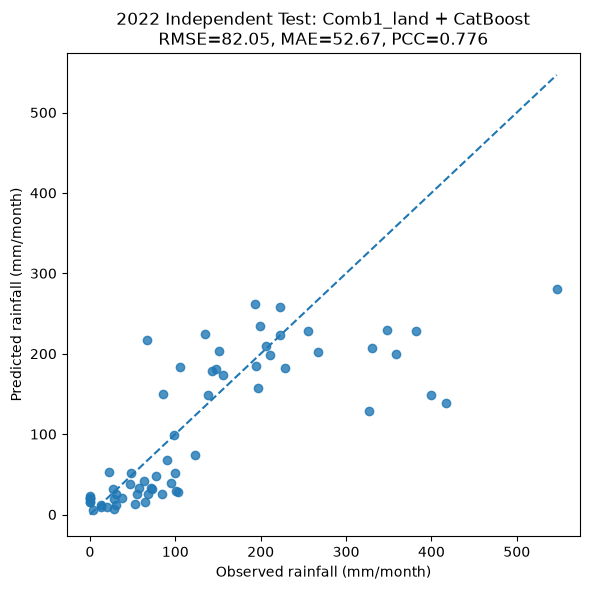

Saved: E:\Geospatial\Precipitation-Downscaling-Khulna\Machine-Learning-Based-Precipitation-Downscaling-over-Khulna-District-Bangladesh\outputs\paper_style_FINAL_v2\06_best_overall_test_scatter.png


In [9]:
# ============================================================
# 9. BEST-OVERALL TEST SCATTER
# ============================================================

import matplotlib.pyplot as plt

best_combo = best_overall["combination"]
best_model_name = best_overall["model"]

scatter_data = test_predictions[
    (test_predictions["combination"] == best_combo)
    & (test_predictions["model"] == best_model_name)
].copy()

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(
    scatter_data["rainfall_mm"],
    scatter_data["predicted_mm"],
    alpha=0.8
)

lo = float(
    min(
        scatter_data["rainfall_mm"].min(),
        scatter_data["predicted_mm"].min()
    )
)

hi = float(
    max(
        scatter_data["rainfall_mm"].max(),
        scatter_data["predicted_mm"].max()
    )
)

ax.plot(
    [lo, hi],
    [lo, hi],
    linestyle="--"
)

ax.set_xlabel(
    "Observed rainfall (mm/month)"
)

ax.set_ylabel(
    "Predicted rainfall (mm/month)"
)

ax.set_title(
    f"2022 Independent Test: {best_combo} + {best_model_name}\n"
    f"RMSE={best_overall['test_RMSE']:.2f}, "
    f"MAE={best_overall['test_MAE']:.2f}, "
    f"PCC={best_overall['test_PCC']:.3f}"
)

fig.tight_layout()

scatter_path = (
    RUN_DIR
    / "06_best_overall_test_scatter.png"
)

fig.savefig(
    scatter_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    scatter_path
)


In [10]:
# ============================================================
# 10. TARGET-GRID HELPERS
# ============================================================

def grid_path(feature, month):

    if feature in [
        "DEM",
        "Distance_Sea",
    ]:
        return (
            GRID_ROOT
            / "static"
            / f"{feature}.tif"
        )

    return (
        GRID_ROOT
        / feature
        / f"{feature}_2022_{month:02d}.tif"
    )


def read_grid(path):
    with rasterio.open(path) as src:

        arr = src.read(
            1
        ).astype(
            "float32"
        )

        nodata = src.nodata

        valid = np.isfinite(
            arr
        )

        if nodata is not None:
            valid &= ~np.isclose(
                arr,
                nodata
            )

        profile = src.profile.copy()

    return (
        arr,
        valid,
        profile
    )


# Use aligned DEM as the study-area mask because Notebook 05
# already masked it to Khulna.
study_mask_path = (
    GRID_ROOT
    / "static"
    / "DEM.tif"
)

if not study_mask_path.exists():
    raise FileNotFoundError(
        study_mask_path
    )

study_dem, study_mask, study_profile = (
    read_grid(
        study_mask_path
    )
)

study_pixels = int(
    study_mask.sum()
)

if study_pixels == 0:
    raise RuntimeError(
        "Study mask contains zero valid pixels."
    )

print(
    "Khulna study-mask pixels:",
    study_pixels
)


Khulna study-mask pixels: 15636


In [11]:
# ============================================================
# 11. SPATIAL PREDICTION FUNCTION
# ============================================================

def predict_month(
    model,
    features,
    month,
    out_path
):

    arrays = []
    masks = []
    profile = None
    shape = None

    for feature in features:

        path = grid_path(
            feature,
            month
        )

        if not path.exists():
            raise FileNotFoundError(
                path
            )

        arr, valid, pr = read_grid(
            path
        )

        if shape is None:
            shape = arr.shape
            profile = pr

        elif arr.shape != shape:
            raise ValueError(
                f"Grid shape mismatch: {path}"
            )

        arrays.append(
            arr
        )

        masks.append(
            valid
        )

    # Combination-specific valid mask.
    valid = (
        np.logical_and.reduce(
            masks
        )
        & study_mask
    )

    out = np.full(
        shape,
        -9999.0,
        dtype="float32"
    )

    if valid.any():

        X = np.column_stack(
            [
                arr[valid]
                for arr in arrays
            ]
        )

        finite_rows = np.all(
            np.isfinite(X),
            axis=1
        )

        prediction = np.full(
            X.shape[0],
            np.nan,
            dtype="float32"
        )

        if finite_rows.any():

            prediction[
                finite_rows
            ] = np.clip(
                model.predict(
                    X[
                        finite_rows
                    ]
                ),
                0,
                None
            ).astype(
                "float32"
            )

        values = np.full(
            X.shape[0],
            -9999.0,
            dtype="float32"
        )

        good = np.isfinite(
            prediction
        )

        values[
            good
        ] = prediction[
            good
        ]

        out[
            valid
        ] = values

    profile.update(
        dtype="float32",
        nodata=-9999.0,
        count=1,
        compress="deflate",
        predictor=3,
    )

    out_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    with rasterio.open(
        out_path,
        "w",
        **profile
    ) as dst:
        dst.write(
            out,
            1
        )

    predicted_mask = (
        study_mask
        & np.isfinite(out)
        & (~np.isclose(out, -9999.0))
    )

    coverage_pct = (
        100.0
        * predicted_mask.sum()
        / study_pixels
    )

    values = out[
        predicted_mask
    ]

    stats = {
        "coverage_pct_inside_khulna": float(
            coverage_pct
        ),
        "valid_pixels": int(
            predicted_mask.sum()
        ),
        "min_mm": (
            float(np.min(values))
            if values.size else np.nan
        ),
        "median_mm": (
            float(np.median(values))
            if values.size else np.nan
        ),
        "mean_mm": (
            float(np.mean(values))
            if values.size else np.nan
        ),
        "max_mm": (
            float(np.max(values))
            if values.size else np.nan
        ),
    }

    return stats


In [12]:
# ============================================================
# 12. GENERATE MONTHLY + ANNUAL SPATIAL OUTPUTS
# ============================================================

if GENERATE_ALL_EXPERIMENT_MAPS:

    spatial_jobs = all_metrics[
        [
            "combination",
            "model",
        ]
    ].drop_duplicates()

else:

    spatial_jobs = selected[
        [
            "combination",
            "model",
        ]
    ].copy()


spatial_qc_rows = []
annual_summary_rows = []


for _, job in spatial_jobs.iterrows():

    combo = job[
        "combination"
    ]

    model_name = job[
        "model"
    ]

    model = final_models[
        (combo, model_name)
    ]

    features = COMBINATIONS[
        combo
    ]

    experiment_dir = (
        RUN_DIR
        / "maps"
        / combo
        / model_name
    )

    experiment_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    monthly_paths = []

    print(
        f"\nSpatial prediction: "
        f"{combo} + {model_name}"
    )

    for month in range(
        1,
        13
    ):

        out_path = (
            experiment_dir
            / f"downscaled_2022_{month:02d}.tif"
        )

        stats = predict_month(
            model,
            features,
            month,
            out_path
        )

        spatial_qc_rows.append({
            "combination": combo,
            "model": model_name,
            "month": month,
            **stats,
        })

        monthly_paths.append(
            out_path
        )


    # --------------------------------------------------------
    # Annual strict sum: valid only when all 12 months valid.
    # Also save valid-month-count raster.
    # --------------------------------------------------------

    stack = []
    valid_stack = []
    profile = None

    for path in monthly_paths:

        arr, valid, pr = read_grid(
            path
        )

        stack.append(
            arr
        )

        valid_stack.append(
            valid & study_mask
        )

        if profile is None:
            profile = pr


    valid_month_count = np.sum(
        np.stack(
            valid_stack,
            axis=0
        ),
        axis=0
    ).astype(
        "uint8"
    )


    all_12_valid = (
        valid_month_count == 12
    ) & study_mask


    annual = np.full(
        stack[0].shape,
        -9999.0,
        dtype="float32"
    )


    if all_12_valid.any():

        annual[
            all_12_valid
        ] = np.sum(
            np.stack(
                [
                    arr[
                        all_12_valid
                    ]
                    for arr in stack
                ],
                axis=0
            ),
            axis=0
        ).astype(
            "float32"
        )


    annual_profile = profile.copy()

    annual_profile.update(
        dtype="float32",
        nodata=-9999.0,
        count=1,
        compress="deflate",
        predictor=3,
    )


    annual_path = (
        experiment_dir
        / "annual_downscaled_2022.tif"
    )


    with rasterio.open(
        annual_path,
        "w",
        **annual_profile
    ) as dst:

        dst.write(
            annual,
            1
        )


    count_profile = profile.copy()

    count_profile.update(
        dtype="uint8",
        nodata=0,
        count=1,
        compress="deflate",
    )


    month_count_path = (
        experiment_dir
        / "valid_month_count_2022.tif"
    )


    count_out = (
        valid_month_count
        .copy()
    )

    count_out[
        ~study_mask
    ] = 0


    with rasterio.open(
        month_count_path,
        "w",
        **count_profile
    ) as dst:

        dst.write(
            count_out,
            1
        )


    annual_valid = (
        all_12_valid
        & np.isfinite(
            annual
        )
        & (~np.isclose(
            annual,
            -9999.0
        ))
    )


    values = annual[
        annual_valid
    ]


    annual_summary_rows.append({
        "combination": combo,
        "model": model_name,
        "annual_valid_pixels": int(
            annual_valid.sum()
        ),
        "annual_coverage_pct_inside_khulna": float(
            100.0
            * annual_valid.sum()
            / study_pixels
        ),
        "min_mm_year": (
            float(np.min(values))
            if values.size else np.nan
        ),
        "p05_mm_year": (
            float(np.percentile(values, 5))
            if values.size else np.nan
        ),
        "median_mm_year": (
            float(np.median(values))
            if values.size else np.nan
        ),
        "mean_mm_year": (
            float(np.mean(values))
            if values.size else np.nan
        ),
        "p95_mm_year": (
            float(np.percentile(values, 95))
            if values.size else np.nan
        ),
        "max_mm_year": (
            float(np.max(values))
            if values.size else np.nan
        ),
        "annual_tif": str(
            annual_path
        ),
        "valid_month_count_tif": str(
            month_count_path
        ),
    })


spatial_qc = pd.DataFrame(
    spatial_qc_rows
)

annual_summary = pd.DataFrame(
    annual_summary_rows
)

spatial_qc.to_csv(
    RUN_DIR
    / "07_spatial_monthly_qc.csv",
    index=False
)

annual_summary.to_csv(
    RUN_DIR
    / "08_annual_2022_summary.csv",
    index=False
)

print("\nMONTHLY SPATIAL QC")
display(
    spatial_qc
)

print("\nANNUAL SPATIAL SUMMARY")
display(
    annual_summary
)



Spatial prediction: Comb1 + XGBoost

Spatial prediction: Comb1_land + CatBoost

Spatial prediction: Comb2 + XGBoost

Spatial prediction: Comb2_land + CatBoost

MONTHLY SPATIAL QC


,combination,model,month,coverage_pct_inside_khulna,valid_pixels,min_mm,median_mm,mean_mm,max_mm
0,Comb1,XGBoost,1,70.715017,11057,18.870106,28.332260,31.494902,44.579784
1,Comb1,XGBoost,2,70.715017,11057,44.685196,61.224560,63.017456,80.132561
2,Comb1,XGBoost,3,70.715017,11057,16.500555,27.987223,27.647011,36.031605
3,Comb1,XGBoost,4,70.715017,11057,26.024254,37.539700,43.239540,72.785286
4,Comb1,XGBoost,5,70.715017,11057,135.189178,178.214508,184.946640,275.260498
5,Comb1,XGBoost,6,70.715017,11057,152.831985,175.956192,187.029297,233.150238
6,Comb1,XGBoost,7,70.715017,11057,70.505768,188.547638,173.185608,252.820236
7,Comb1,XGBoost,8,7.879253,1232,182.889420,198.997726,204.727921,253.737122
8,Comb1,XGBoost,9,70.715017,11057,172.849258,234.540070,244.072449,327.487335
9,Comb1,XGBoost,10,70.715017,11057,129.003159,176.065140,177.332260,219.066589



ANNUAL SPATIAL SUMMARY


,combination,model,annual_valid_pixels,annual_coverage_pct_inside_khulna,min_mm_year,p05_mm_year,median_mm_year,mean_mm_year,p95_mm_year,max_mm_year,annual_tif,valid_month_count_tif
0,Comb1,XGBoost,1232,7.879253,1205.627075,1231.092529,1293.427246,1296.137695,1364.031250,1427.193481,E:\Geospatial\Precipitation-Downscaling-Khulna...,E:\Geospatial\Precipitation-Downscaling-Khulna...
1,Comb1_land,CatBoost,192,1.227936,1277.021240,1311.702148,1661.583252,1616.599976,1731.821045,1826.323730,E:\Geospatial\Precipitation-Downscaling-Khulna...,E:\Geospatial\Precipitation-Downscaling-Khulna...
2,Comb2,XGBoost,11582,74.072653,1205.334839,1259.957275,1464.941406,1465.778564,1690.502930,1842.092163,E:\Geospatial\Precipitation-Downscaling-Khulna...,E:\Geospatial\Precipitation-Downscaling-Khulna...
3,Comb2_land,CatBoost,2819,18.028908,1265.749634,1518.866577,1785.901978,1774.023438,2107.030273,2343.267090,E:\Geospatial\Precipitation-Downscaling-Khulna...,E:\Geospatial\Precipitation-Downscaling-Khulna...


In [13]:
# ============================================================
# 13. OBSERVED 2022 ANNUAL GAUGE QC
# ============================================================

observed_2022 = (
    data[
        data["year"] == 2022
    ]
    .groupby(
        "station_id",
        as_index=False
    )
    .agg(
        observed_annual_mm=(
            "rainfall_mm",
            "sum"
        ),
        months=(
            "rainfall_mm",
            "count"
        ),
    )
)

print(
    "\nOBSERVED 2022 ANNUAL GAUGE RAINFALL"
)

display(
    observed_2022
)

observed_2022.to_csv(
    RUN_DIR
    / "09_observed_2022_annual_gauge.csv",
    index=False
)


if (
    not annual_summary.empty
    and len(
        observed_2022
    ) > 0
):

    obs_min = float(
        observed_2022[
            "observed_annual_mm"
        ].min()
    )

    obs_max = float(
        observed_2022[
            "observed_annual_mm"
        ].max()
    )

    print(
        f"\nObserved 2022 station annual range: "
        f"{obs_min:.1f} to {obs_max:.1f} mm/year"
    )

    print(
        "The spatial prediction is NOT clipped to this range. "
        "Use this only as a plausibility reference."
    )



OBSERVED 2022 ANNUAL GAUGE RAINFALL


,station_id,observed_annual_mm,months
0,CL503,2398.8,12
1,CL504,1548.3,12
2,CL509,1808.3,12
3,CL510,1823.0,12
4,CL515,1782.5,12
5,CL517,1574.6,12



Observed 2022 station annual range: 1548.3 to 2398.8 mm/year
The spatial prediction is NOT clipped to this range. Use this only as a plausibility reference.


In [14]:
# ============================================================
# 14. FINAL OUTPUT SUMMARY
# ============================================================

print(
    "\n=========================================="
)

print(
    "07 FINAL MODELLING + DOWNSCALING COMPLETE"
)

print(
    "=========================================="
)

print(
    "Main metrics:",
    RUN_DIR
    / "03_model_metrics_validation_and_test.csv"
)

print(
    "Selected models:",
    RUN_DIR
    / "04_selected_models_by_validation.csv"
)

print(
    "2022 station predictions:",
    RUN_DIR
    / "05_test2022_station_predictions.csv"
)

print(
    "Best-model scatter:",
    RUN_DIR
    / "06_best_overall_test_scatter.png"
)

print(
    "Monthly spatial QC:",
    RUN_DIR
    / "07_spatial_monthly_qc.csv"
)

print(
    "Annual spatial summary:",
    RUN_DIR
    / "08_annual_2022_summary.csv"
)

print(
    "Spatial maps:",
    RUN_DIR
    / "maps"
)

print(
    "\nIMPORTANT INTERPRETATION:"
)

print(
    "1) 2022 is an independent temporal test year."
)

print(
    "2) Model/hyperparameter selection used validation data, not test metrics."
)

print(
    "3) Missing target-grid inputs remain NoData; no raster-wide filling is used."
)

print(
    "4) Annual maps require all 12 monthly predictions to be valid."
)

print(
    "5) The 0.005-degree raster is an output grid spacing; "
    "effective spatial information is constrained by native predictor resolutions."
)



07 FINAL MODELLING + DOWNSCALING COMPLETE
Main metrics: E:\Geospatial\Precipitation-Downscaling-Khulna\Machine-Learning-Based-Precipitation-Downscaling-over-Khulna-District-Bangladesh\outputs\paper_style_FINAL_v2\03_model_metrics_validation_and_test.csv
Selected models: E:\Geospatial\Precipitation-Downscaling-Khulna\Machine-Learning-Based-Precipitation-Downscaling-over-Khulna-District-Bangladesh\outputs\paper_style_FINAL_v2\04_selected_models_by_validation.csv
2022 station predictions: E:\Geospatial\Precipitation-Downscaling-Khulna\Machine-Learning-Based-Precipitation-Downscaling-over-Khulna-District-Bangladesh\outputs\paper_style_FINAL_v2\05_test2022_station_predictions.csv
Best-model scatter: E:\Geospatial\Precipitation-Downscaling-Khulna\Machine-Learning-Based-Precipitation-Downscaling-over-Khulna-District-Bangladesh\outputs\paper_style_FINAL_v2\06_best_overall_test_scatter.png
Monthly spatial QC: E:\Geospatial\Precipitation-Downscaling-Khulna\Machine-Learning-Based-Precipitation-D


VALIDATION + TEST METRICS


,combination,model,valid_MAE,valid_RMSE,valid_PCC,valid_R2,test_MAE,test_RMSE,test_PCC,test_R2
0,Comb1,XGBoost,66.063022,90.296959,0.832020,0.529390,67.940303,97.747976,0.693512,0.409568
1,Comb1,CatBoost,75.974216,102.500389,0.818981,0.393591,65.095782,96.260396,0.700490,0.427402
2,Comb1,RandomForest,76.319838,103.610179,0.808652,0.380389,68.805472,99.933382,0.674977,0.382871
3,Comb1,LightGBM,81.019584,112.363005,0.829336,0.271279,66.694247,95.710336,0.687353,0.433927
4,Comb1_land,CatBoost,56.643425,79.281401,0.864850,0.489032,52.668939,82.050602,0.775660,0.551037
5,Comb1_land,XGBoost,59.636387,84.215931,0.844240,0.423447,57.114045,91.713314,0.695609,0.439066
6,Comb1_land,RandomForest,68.843853,94.456996,0.839137,0.274698,58.880821,88.364312,0.725551,0.479284
7,Comb1_land,LightGBM,67.219072,101.245691,0.898934,0.166695,65.163457,100.466266,0.634136,0.326888
8,Comb2,XGBoost,72.184781,109.821095,0.800939,0.341255,64.319603,100.801648,0.705959,0.419937
9,Comb2,RandomForest,75.894526,110.083668,0.783905,0.338101,64.938531,94.240250,0.766658,0.492994



SELECTED BEST MODEL PER COMBINATION


,combination,model,valid_RMSE,valid_MAE,valid_PCC,test_RMSE,test_MAE,test_PCC
0,Comb1,XGBoost,90.296959,66.063022,0.832020,97.747976,67.940303,0.693512
1,Comb1_land,CatBoost,79.281401,56.643425,0.864850,82.050602,52.668939,0.775660
2,Comb2,XGBoost,109.821095,72.184781,0.800939,100.801648,64.319603,0.705959
3,Comb2_land,CatBoost,84.782678,58.224703,0.859790,86.579903,53.356075,0.779645


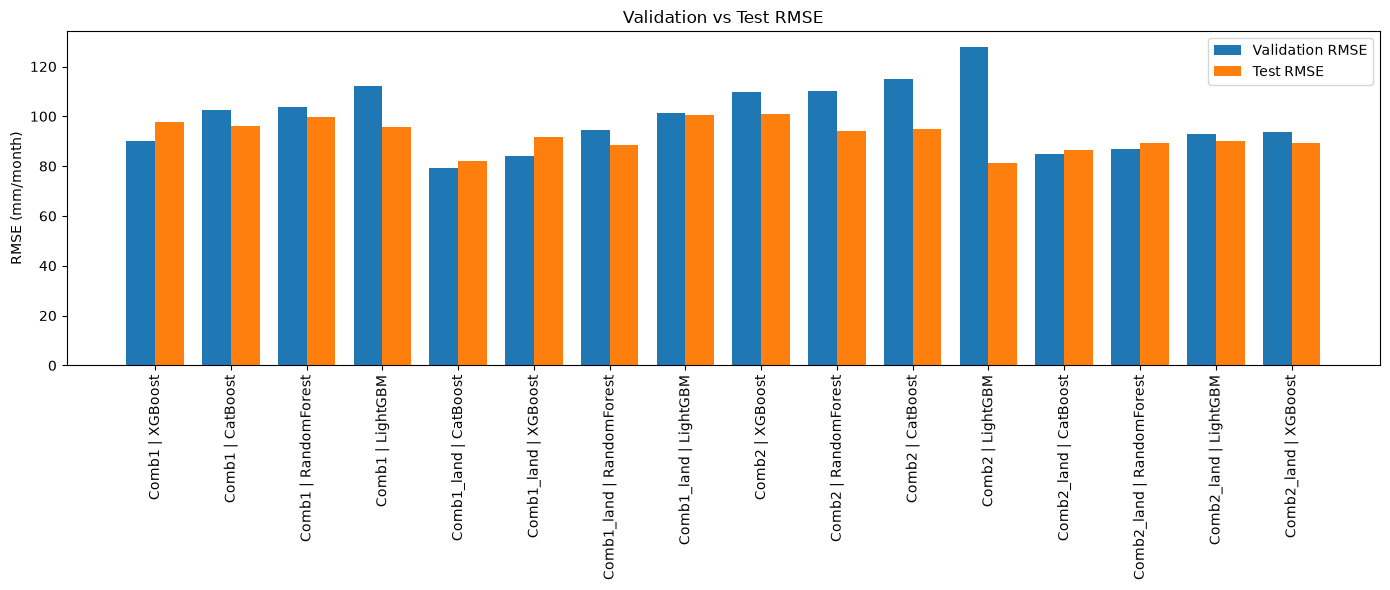

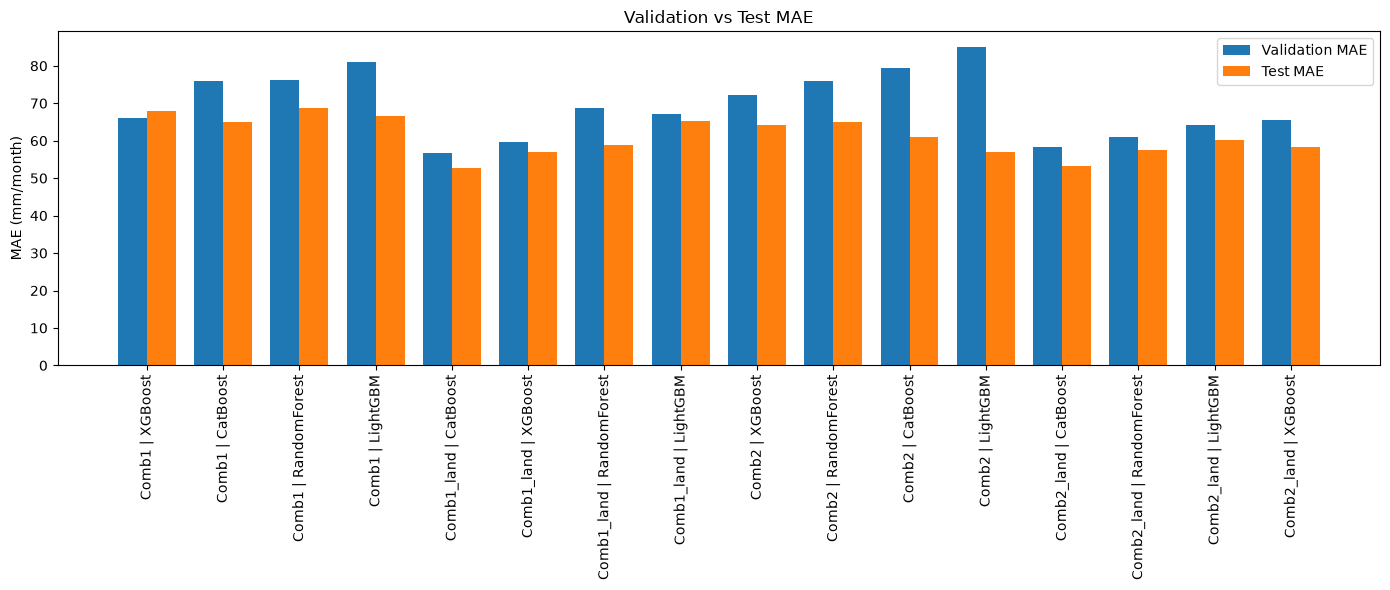

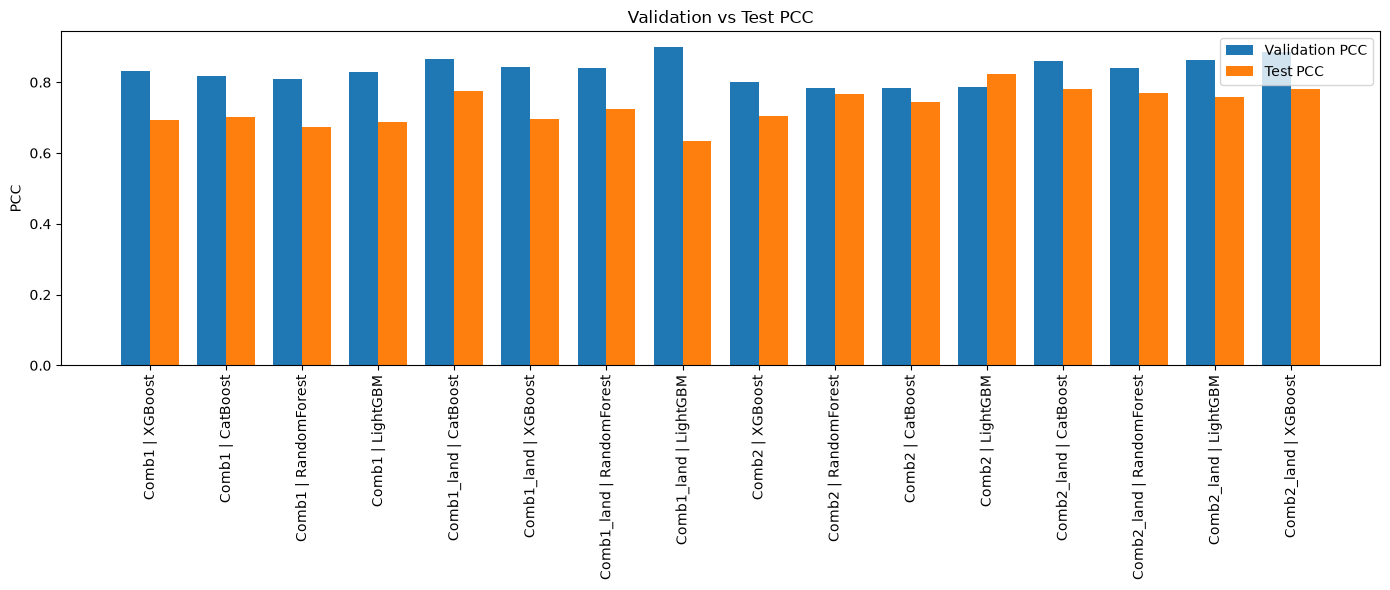


BEST OVERALL TEST SCATTER


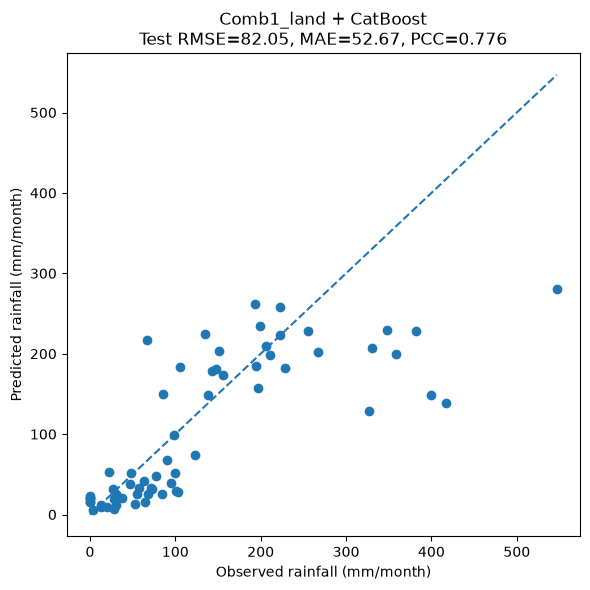


2022 STATION PREDICTIONS


,station_id,month,combination,model,rainfall_mm,predicted_mm,error_mm,abs_error_mm
0,CL503,1,Comb1,XGBoost,0.0,40.914959,40.914959,40.914959
1,CL503,2,Comb1,XGBoost,22.6,62.349926,39.749926,39.749926
2,CL503,3,Comb1,XGBoost,123.3,27.158958,-96.141042,96.141042
3,CL503,4,Comb1,XGBoost,98.3,36.861824,-61.438176,61.438176
4,CL503,5,Comb1,XGBoost,199.0,152.182846,-46.817154,46.817154
...,...,...,...,...,...,...,...,...
267,CL517,8,Comb2_land,CatBoost,330.3,221.112664,-109.187336,109.187336
268,CL517,9,Comb2_land,CatBoost,135.1,221.627358,86.527358,86.527358
269,CL517,10,Comb2_land,CatBoost,151.7,283.677782,131.977782,131.977782
270,CL517,11,Comb2_land,CatBoost,13.2,18.166583,4.966583,4.966583



MONTHLY SPATIAL QC


,combination,model,month,coverage_pct_inside_khulna,valid_pixels,min_mm,median_mm,mean_mm,max_mm
0,Comb1,XGBoost,1,70.715017,11057,18.870106,28.332260,31.494902,44.579784
1,Comb1,XGBoost,2,70.715017,11057,44.685196,61.224560,63.017456,80.132561
2,Comb1,XGBoost,3,70.715017,11057,16.500555,27.987223,27.647011,36.031605
3,Comb1,XGBoost,4,70.715017,11057,26.024254,37.539700,43.239540,72.785286
4,Comb1,XGBoost,5,70.715017,11057,135.189178,178.214508,184.946640,275.260498
5,Comb1,XGBoost,6,70.715017,11057,152.831985,175.956192,187.029297,233.150238
6,Comb1,XGBoost,7,70.715017,11057,70.505768,188.547638,173.185608,252.820236
7,Comb1,XGBoost,8,7.879253,1232,182.889420,198.997726,204.727921,253.737122
8,Comb1,XGBoost,9,70.715017,11057,172.849258,234.540070,244.072449,327.487335
9,Comb1,XGBoost,10,70.715017,11057,129.003159,176.065140,177.332260,219.066589


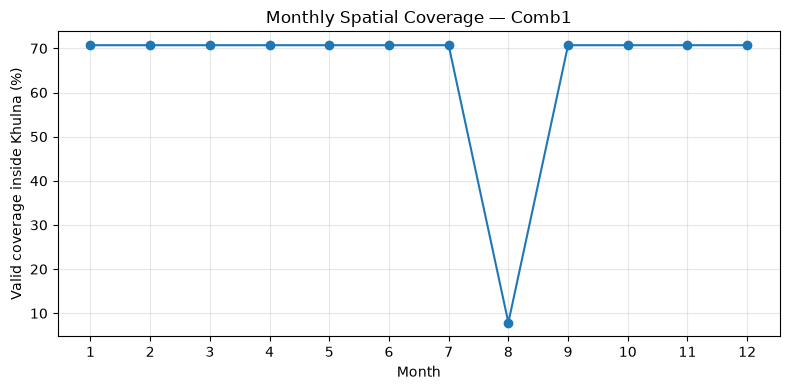

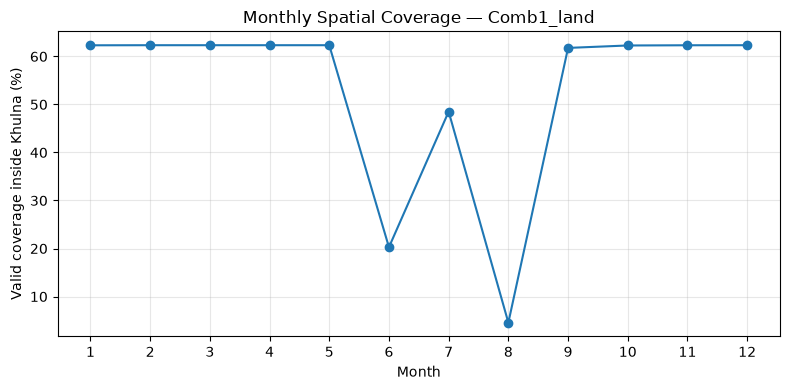

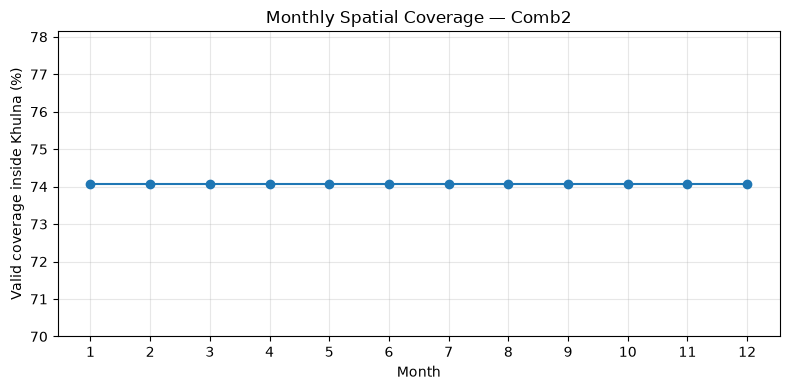

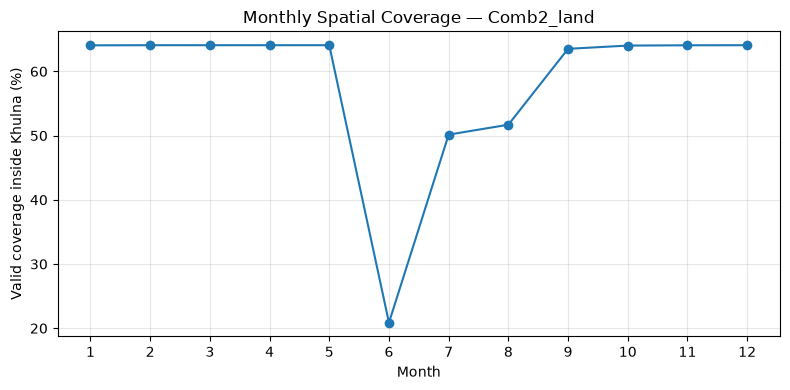


ANNUAL 2022 SUMMARY


,combination,model,annual_valid_pixels,annual_coverage_pct_inside_khulna,min_mm_year,p05_mm_year,median_mm_year,mean_mm_year,p95_mm_year,max_mm_year,annual_tif,valid_month_count_tif
0,Comb1,XGBoost,1232,7.879253,1205.627075,1231.092529,1293.427246,1296.137695,1364.031250,1427.193481,E:\Geospatial\Precipitation-Downscaling-Khulna...,E:\Geospatial\Precipitation-Downscaling-Khulna...
1,Comb1_land,CatBoost,192,1.227936,1277.021240,1311.702148,1661.583252,1616.599976,1731.821045,1826.323730,E:\Geospatial\Precipitation-Downscaling-Khulna...,E:\Geospatial\Precipitation-Downscaling-Khulna...
2,Comb2,XGBoost,11582,74.072653,1205.334839,1259.957275,1464.941406,1465.778564,1690.502930,1842.092163,E:\Geospatial\Precipitation-Downscaling-Khulna...,E:\Geospatial\Precipitation-Downscaling-Khulna...
3,Comb2_land,CatBoost,2819,18.028908,1265.749634,1518.866577,1785.901978,1774.023438,2107.030273,2343.267090,E:\Geospatial\Precipitation-Downscaling-Khulna...,E:\Geospatial\Precipitation-Downscaling-Khulna...


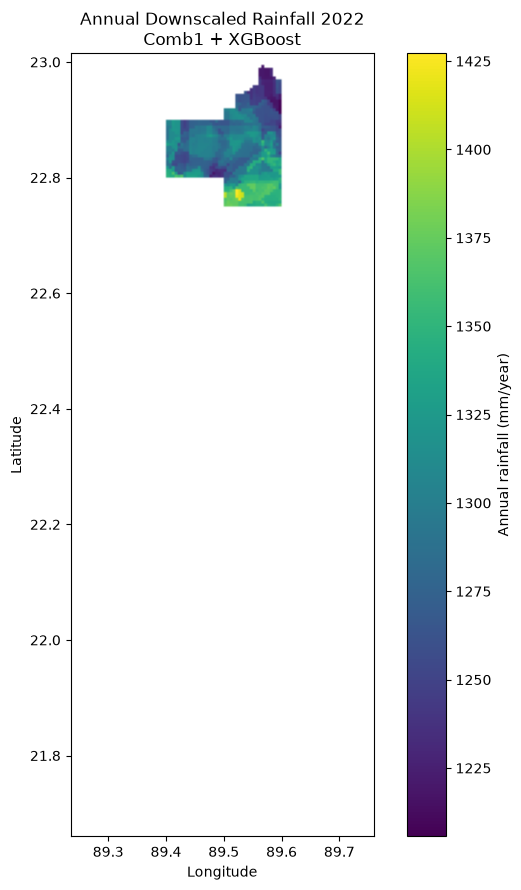

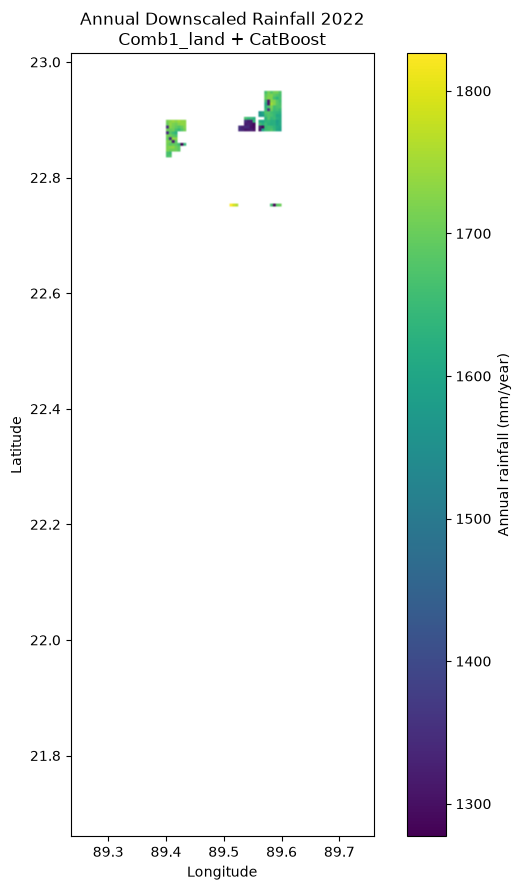

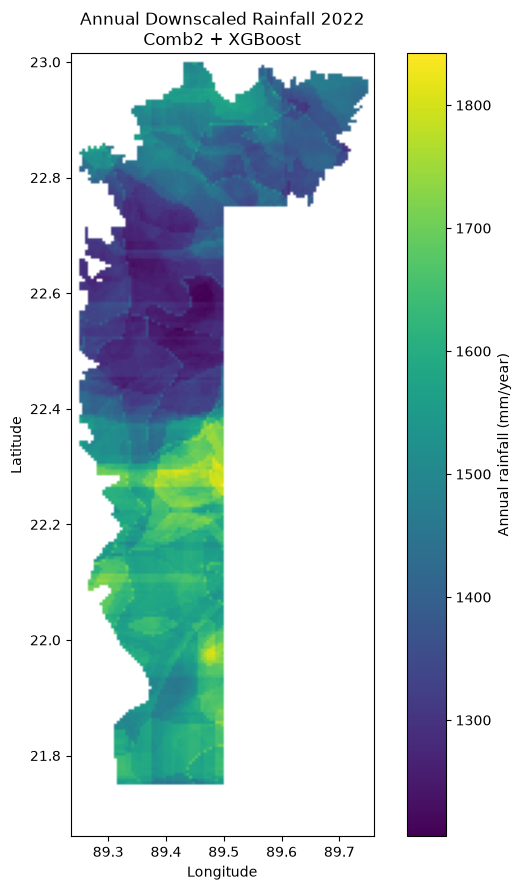

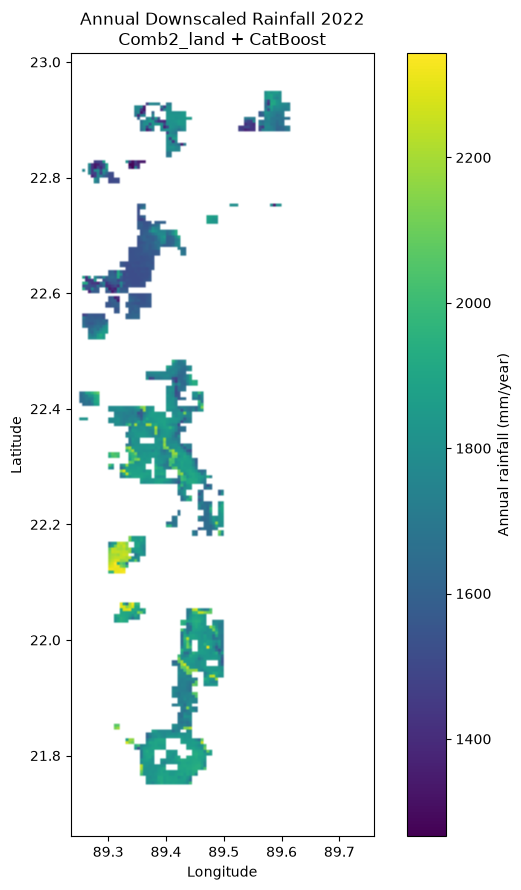


MONTHLY MAPS: Comb1 + XGBoost


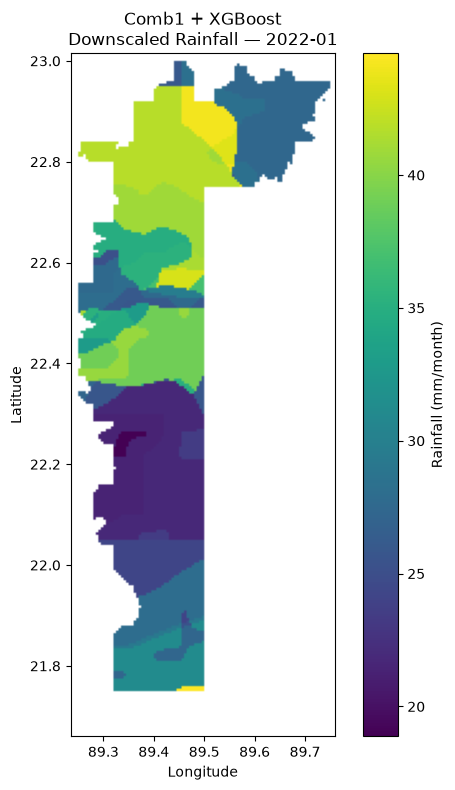

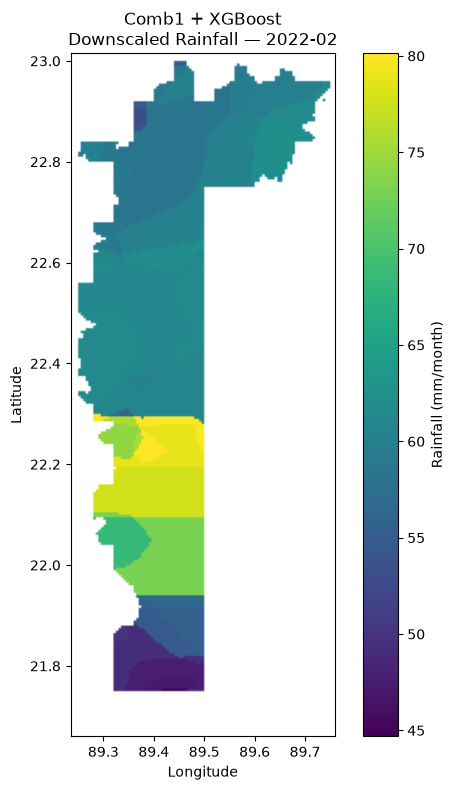

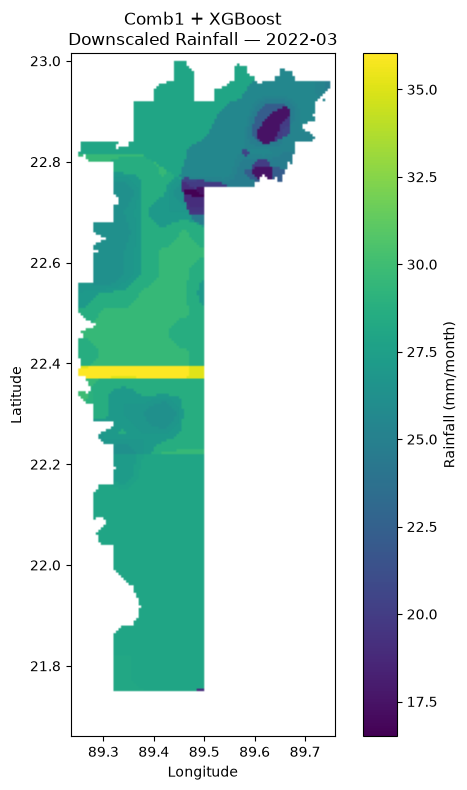

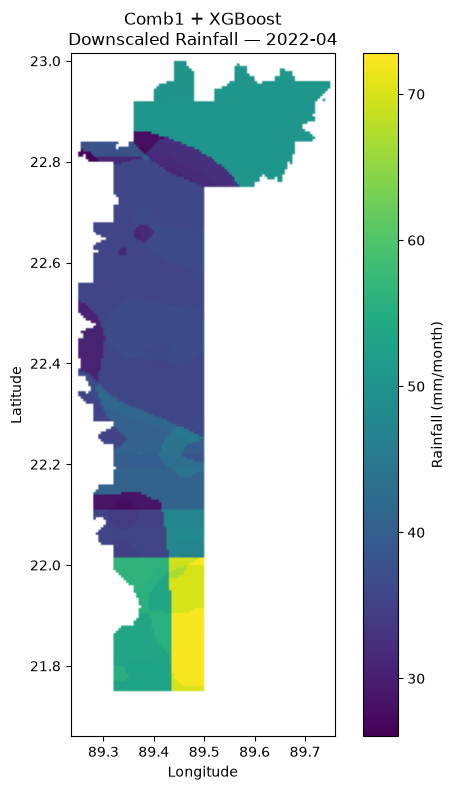

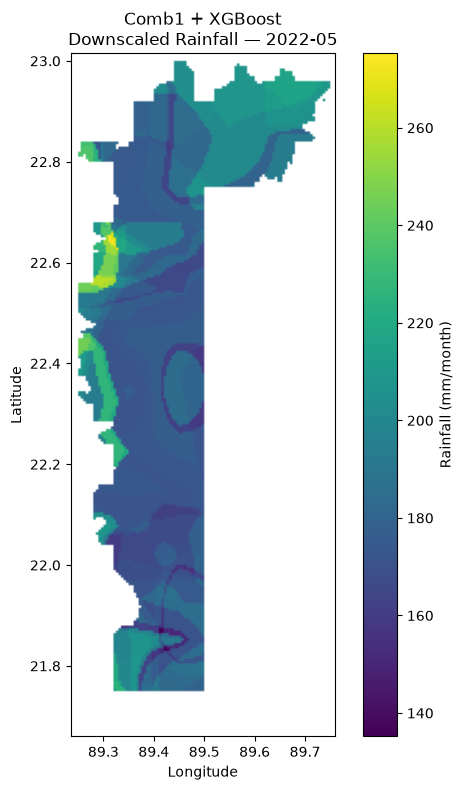

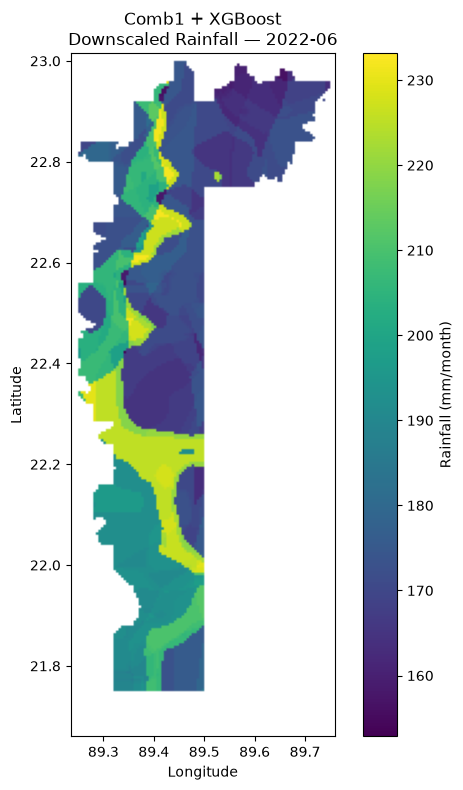

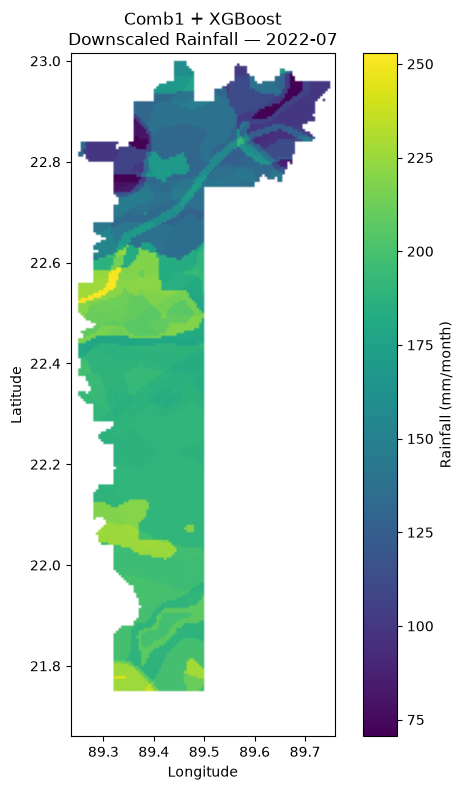

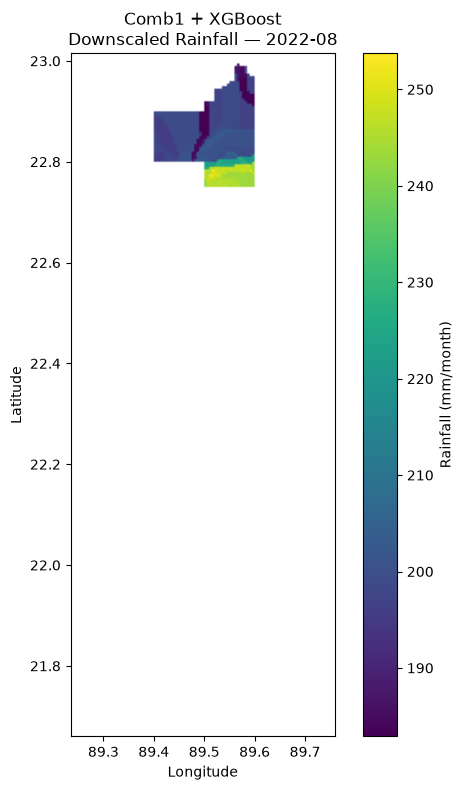

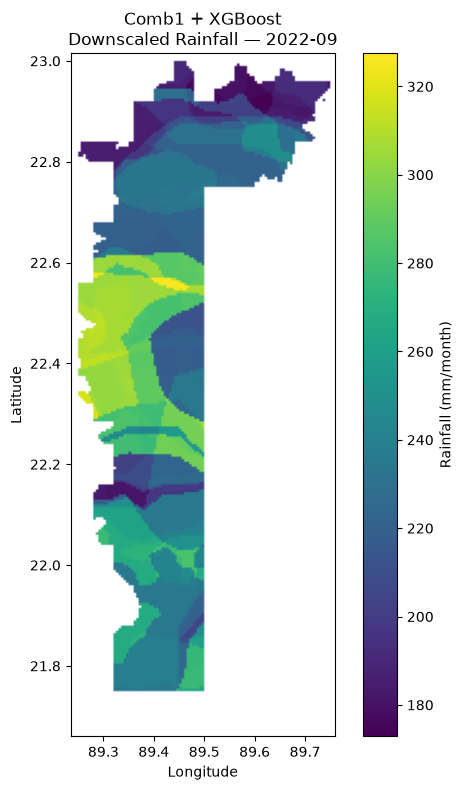

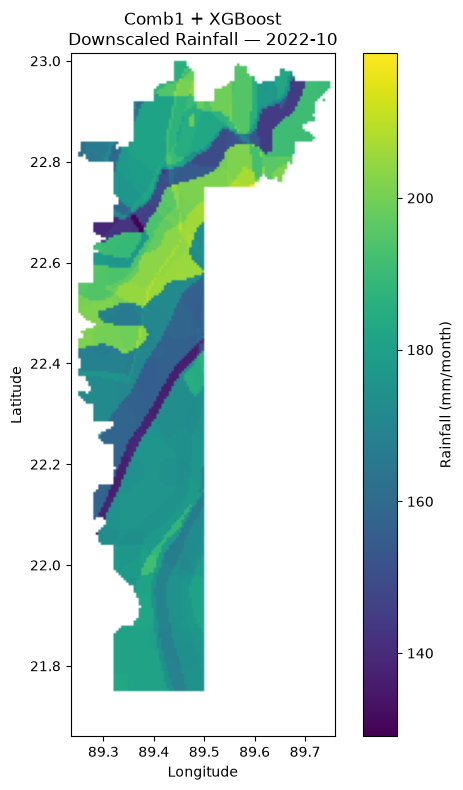

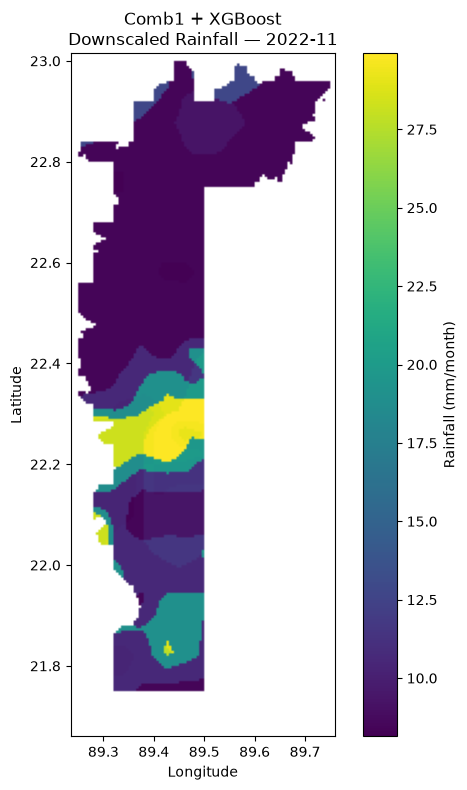

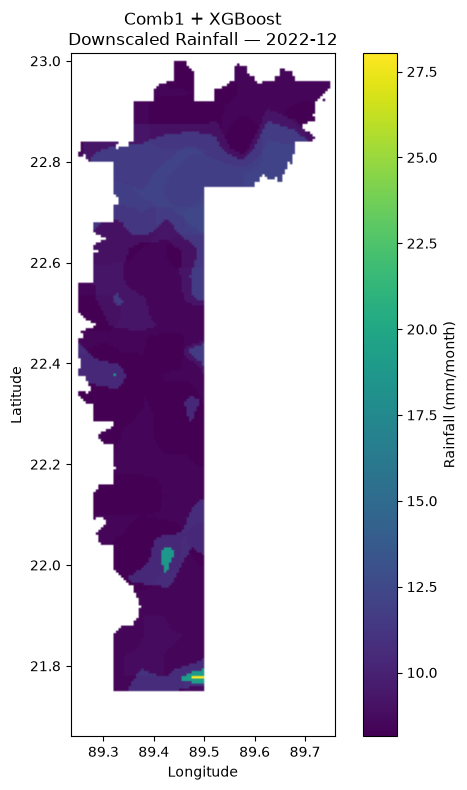


MONTHLY MAPS: Comb1_land + CatBoost


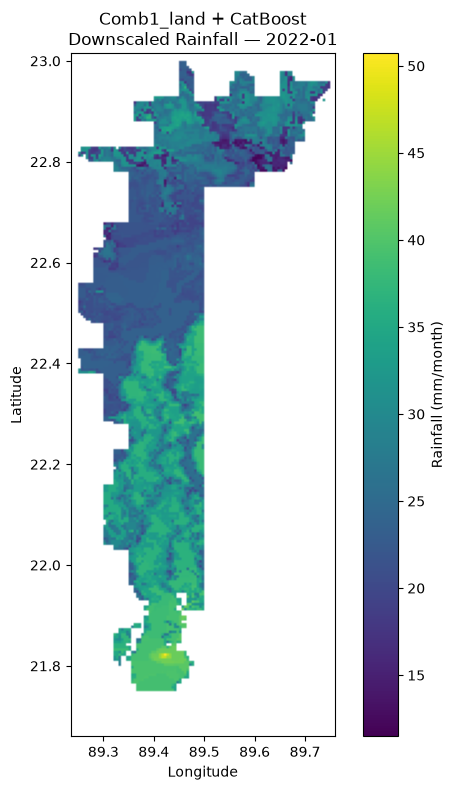

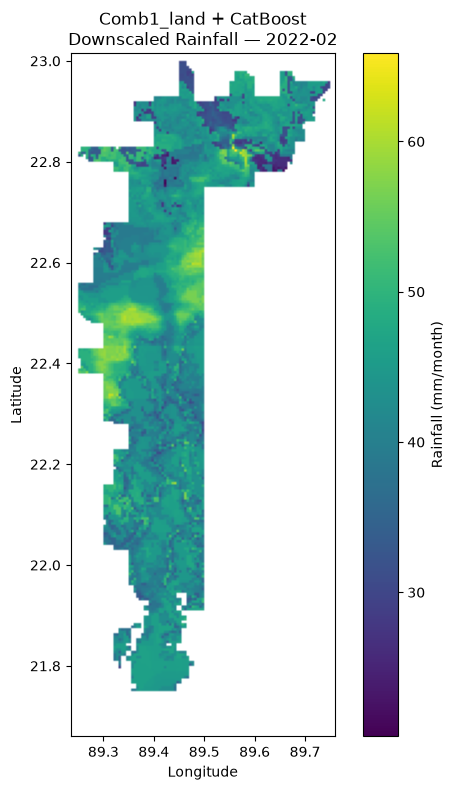

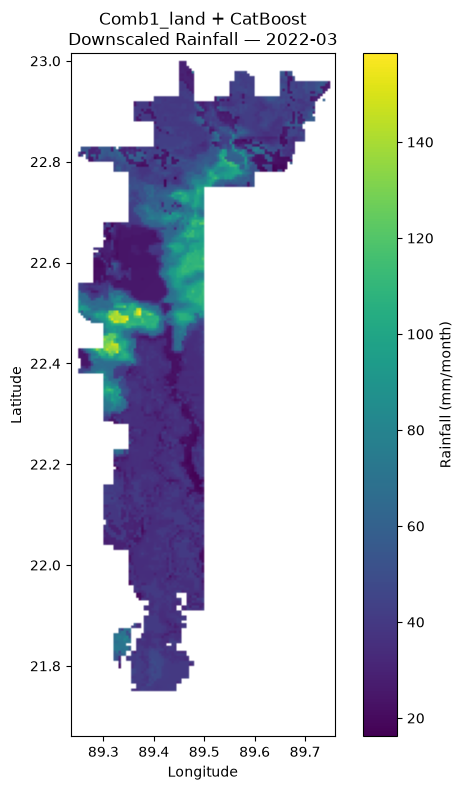

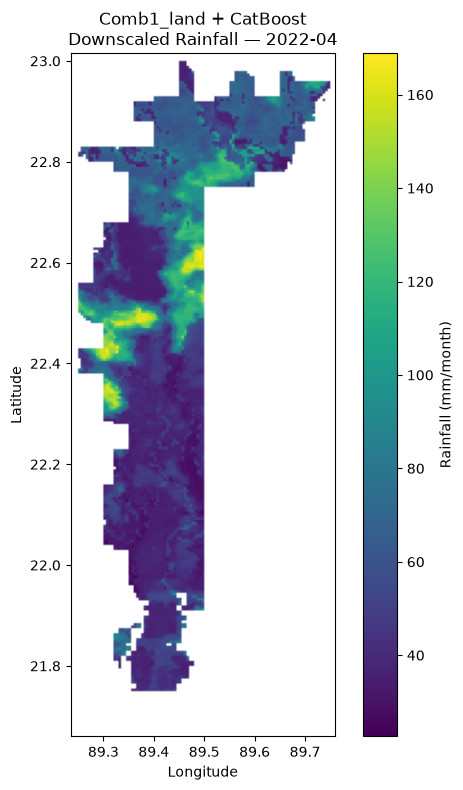

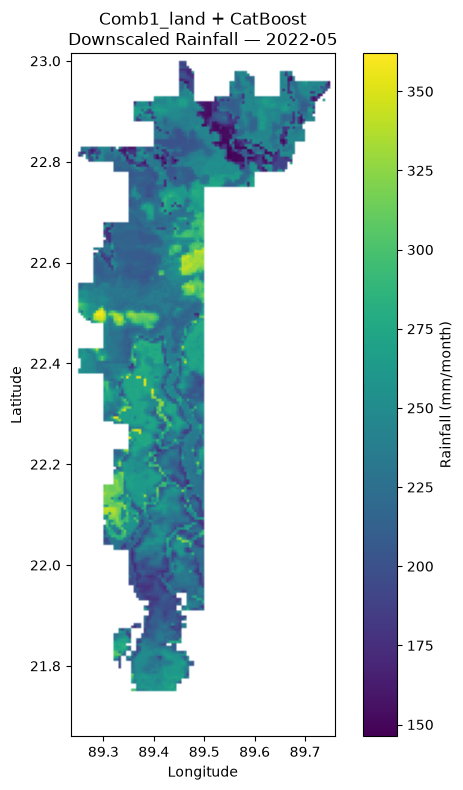

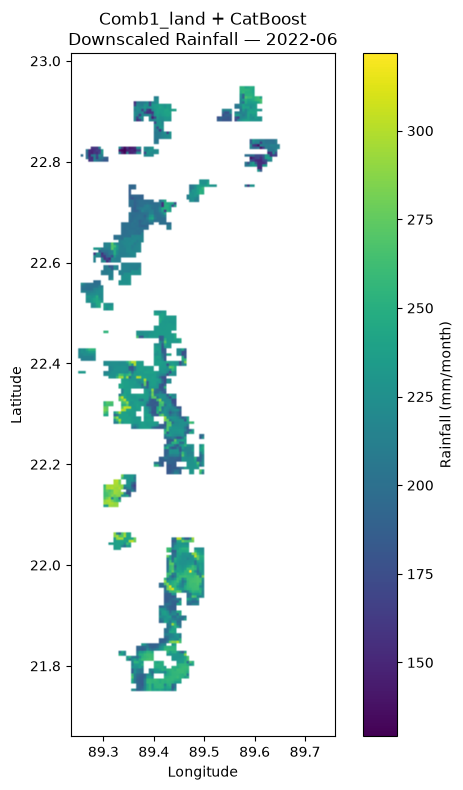

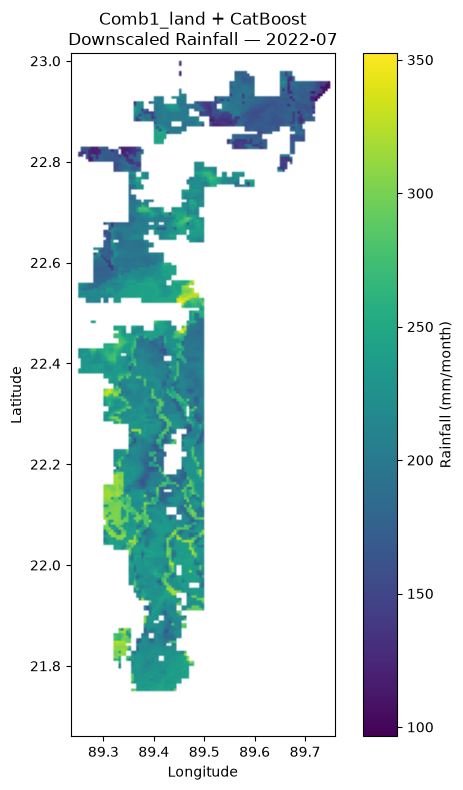

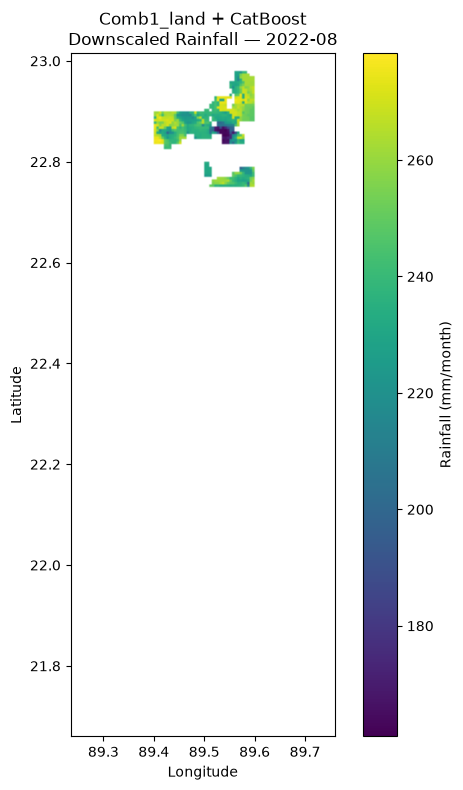

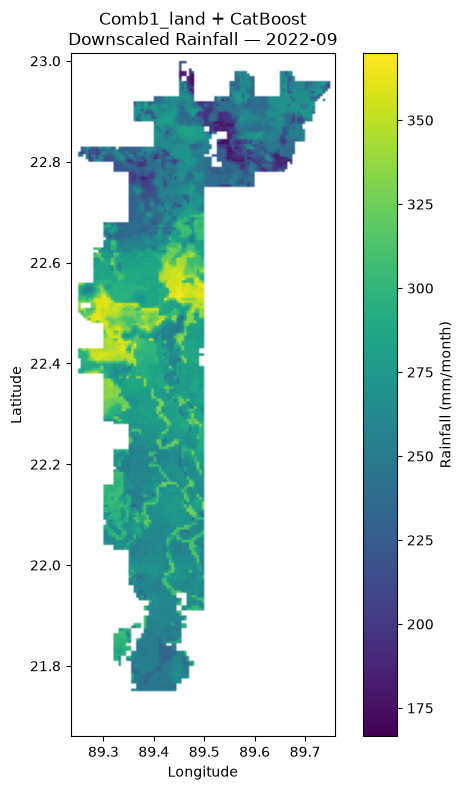

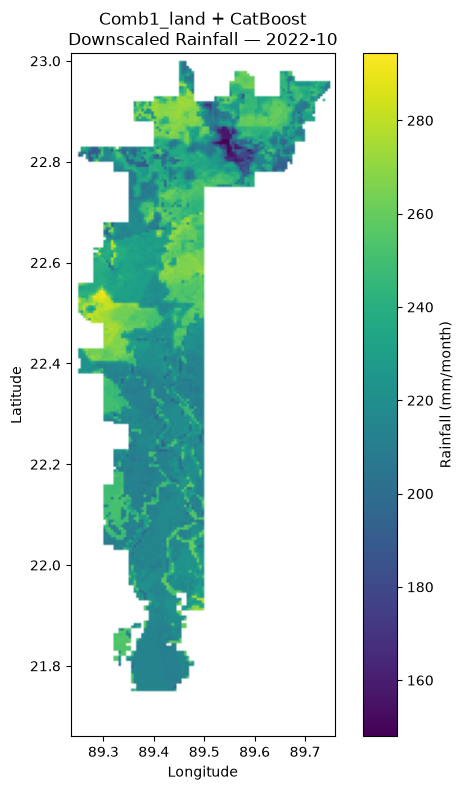

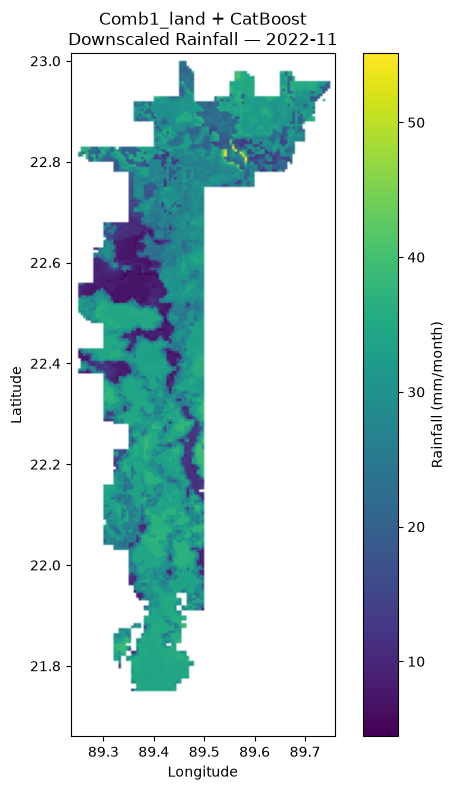

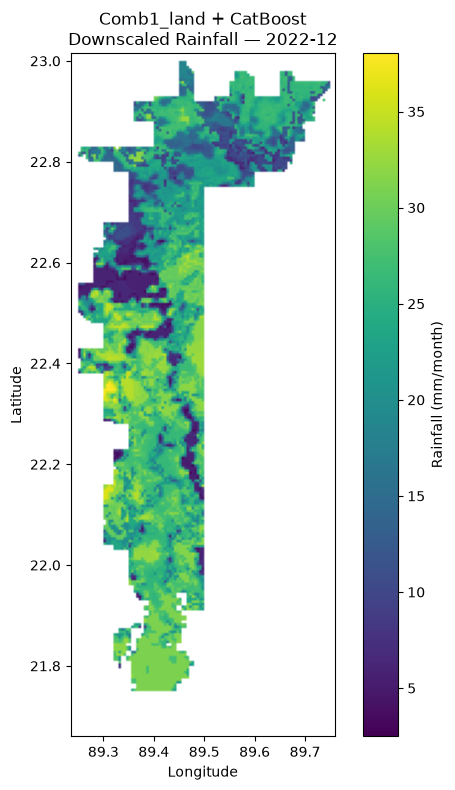


MONTHLY MAPS: Comb2 + XGBoost


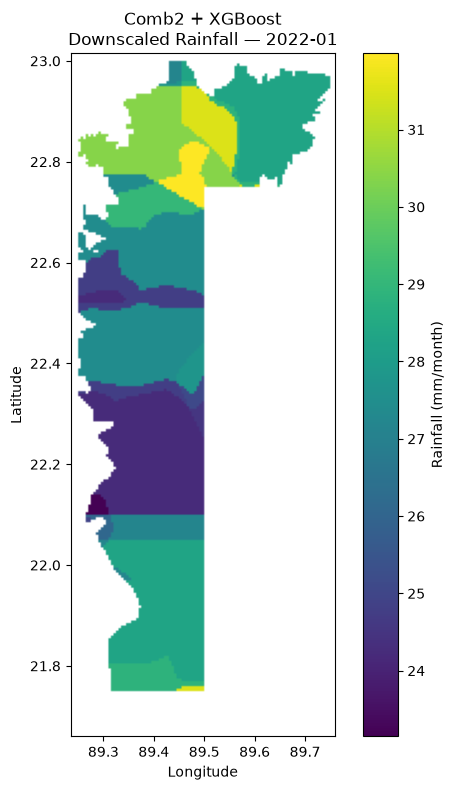

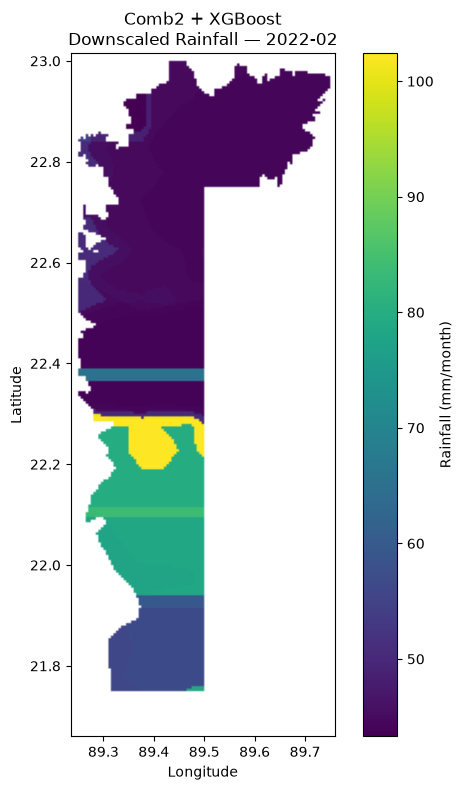

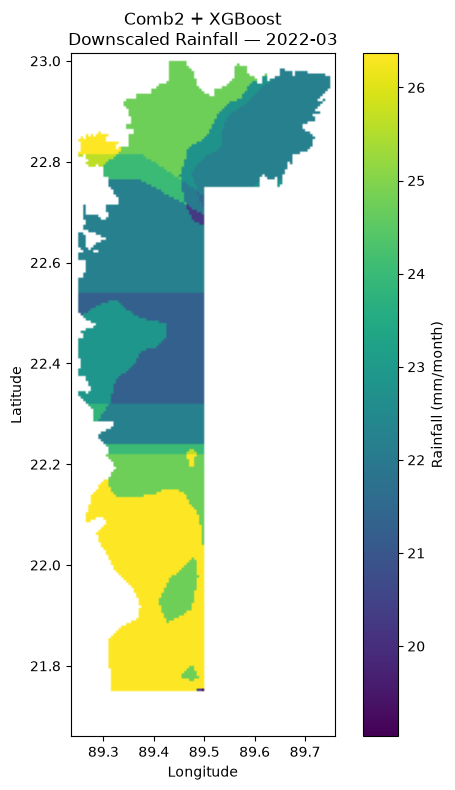

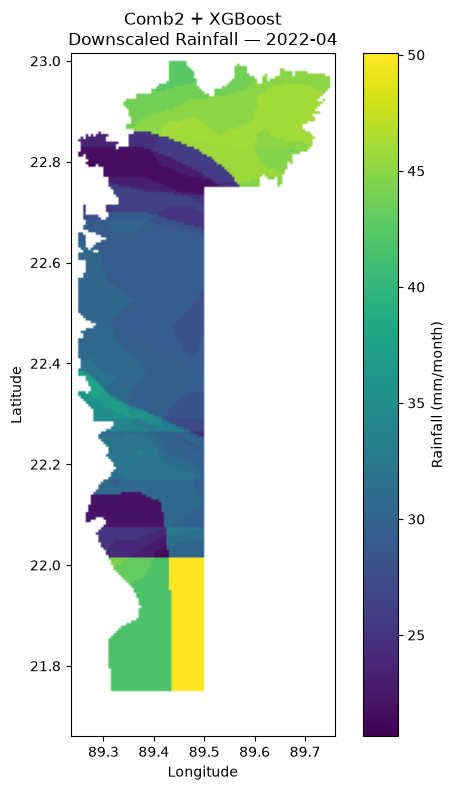

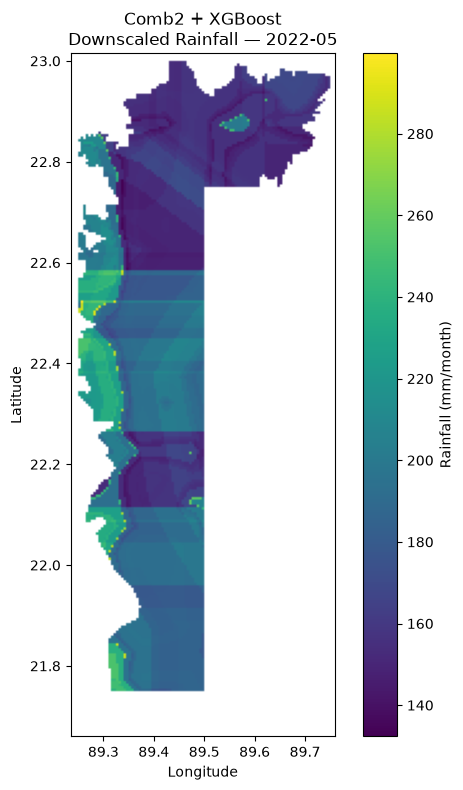

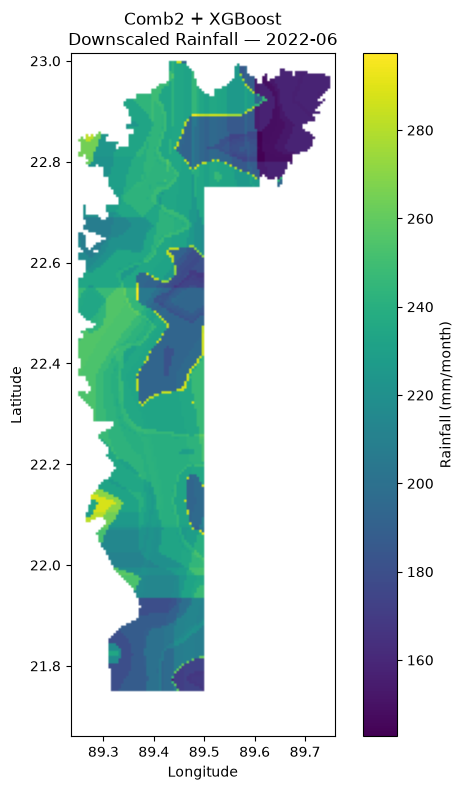

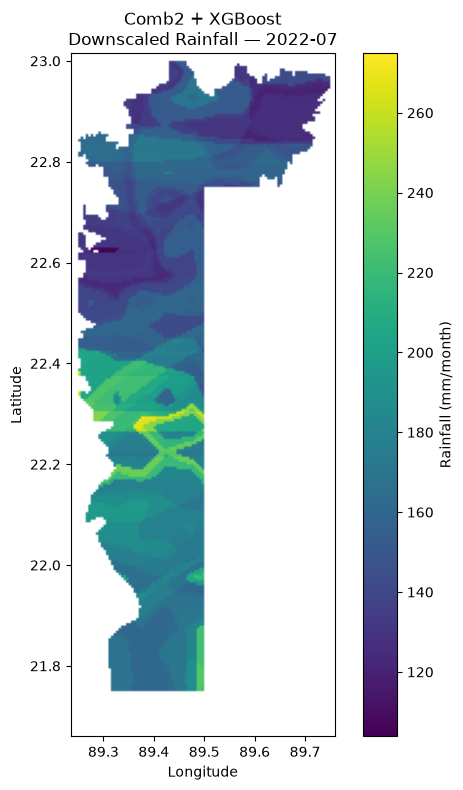

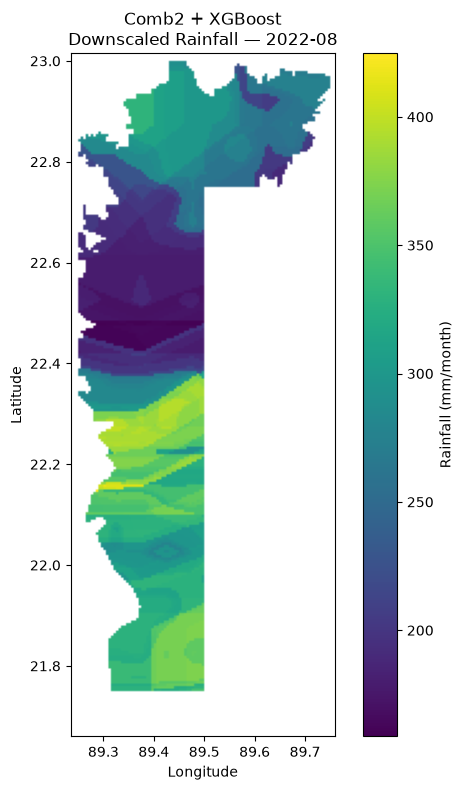

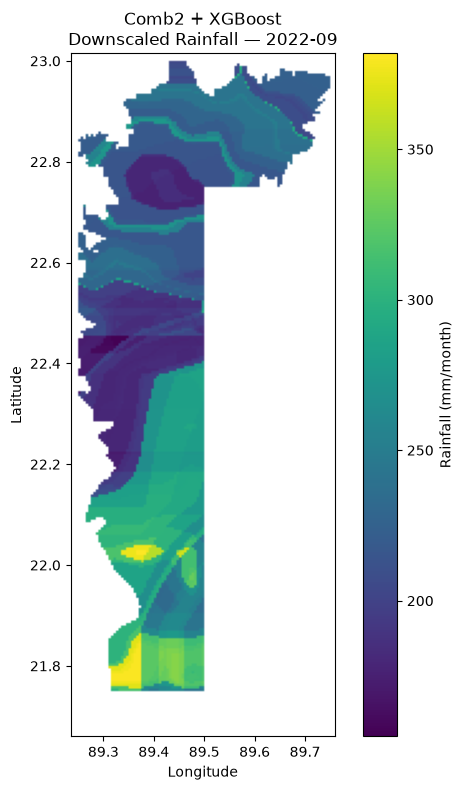

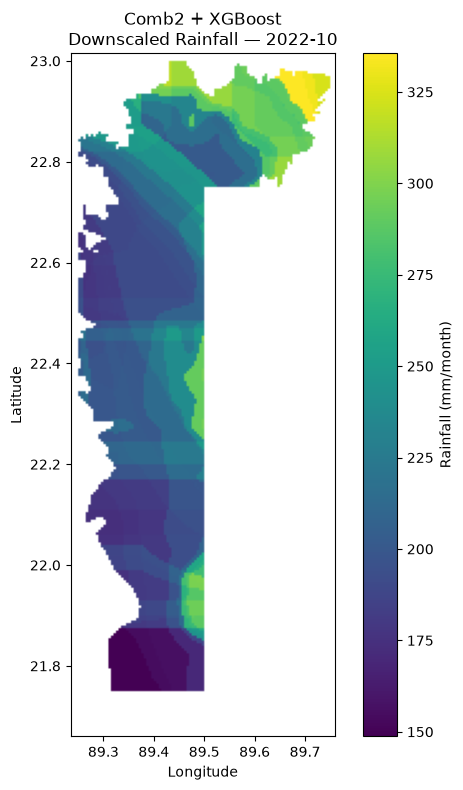

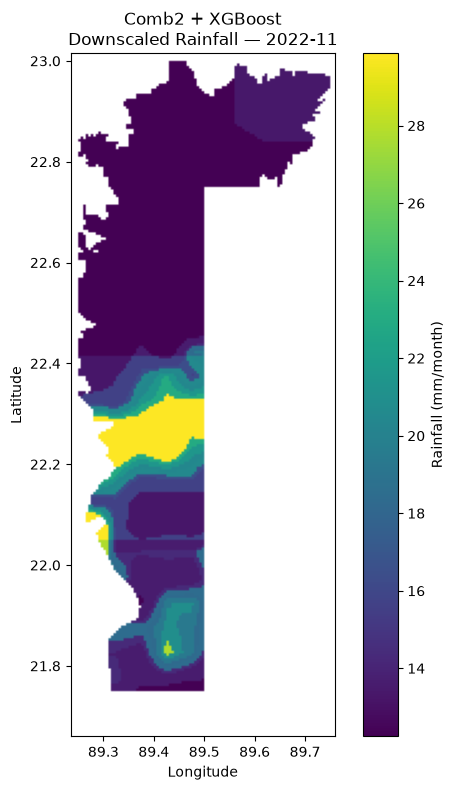

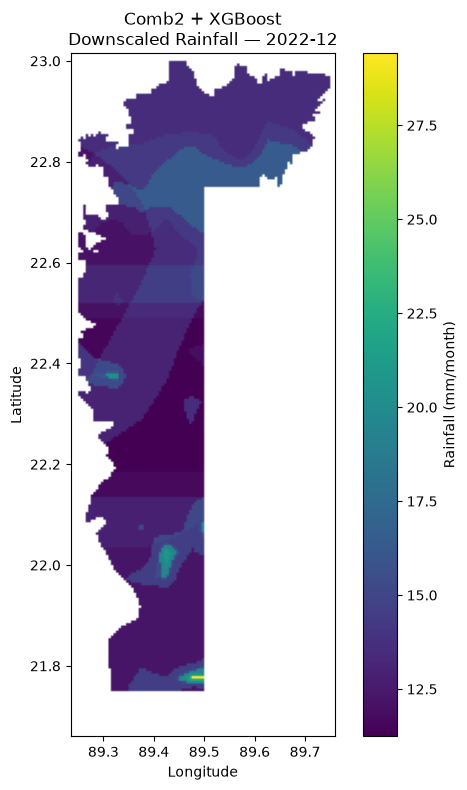


MONTHLY MAPS: Comb2_land + CatBoost


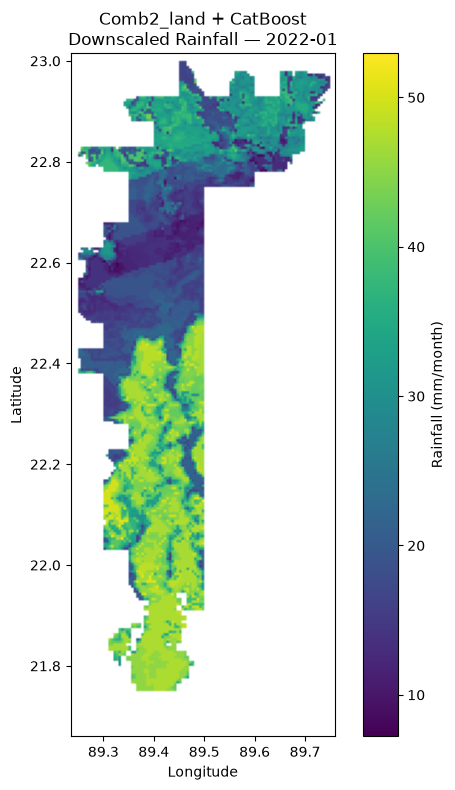

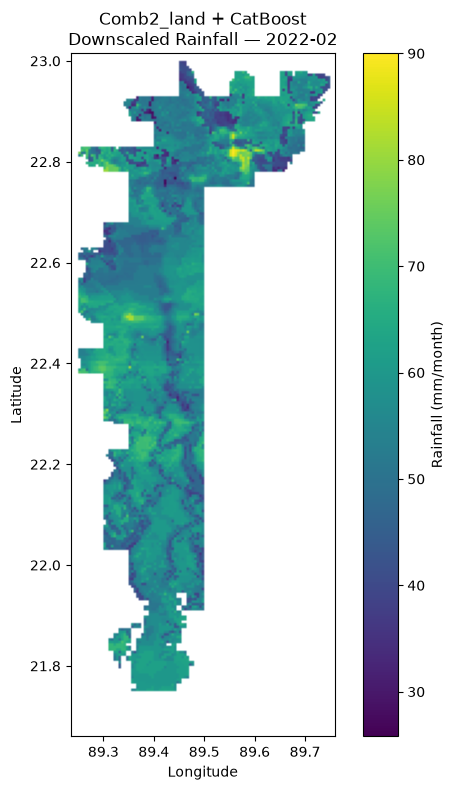

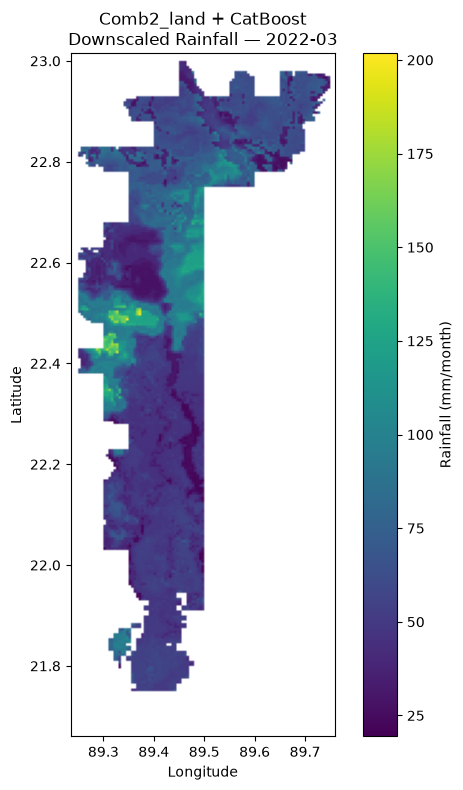

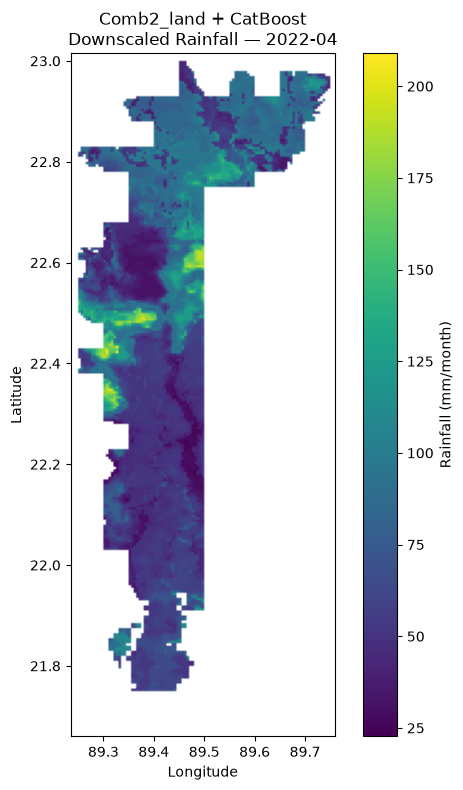

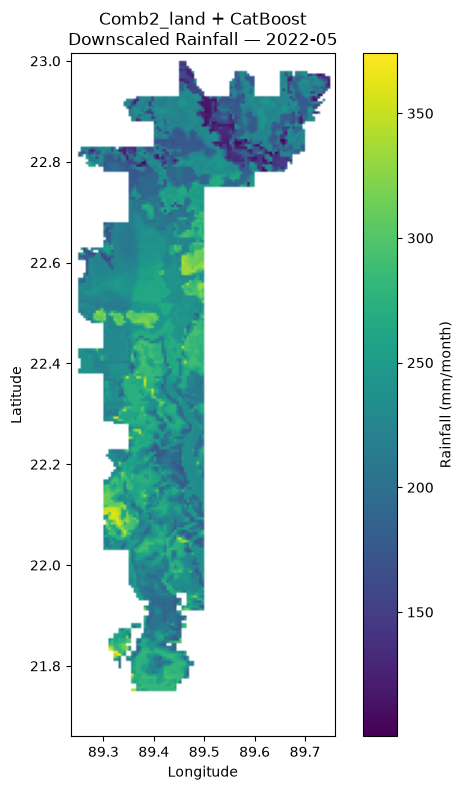

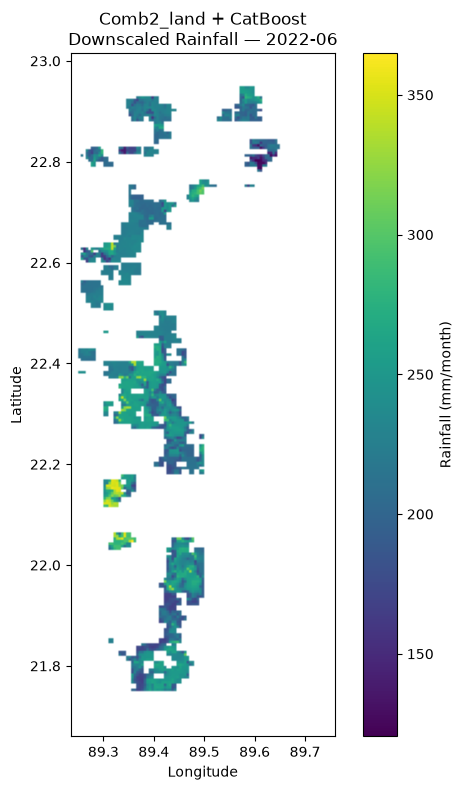

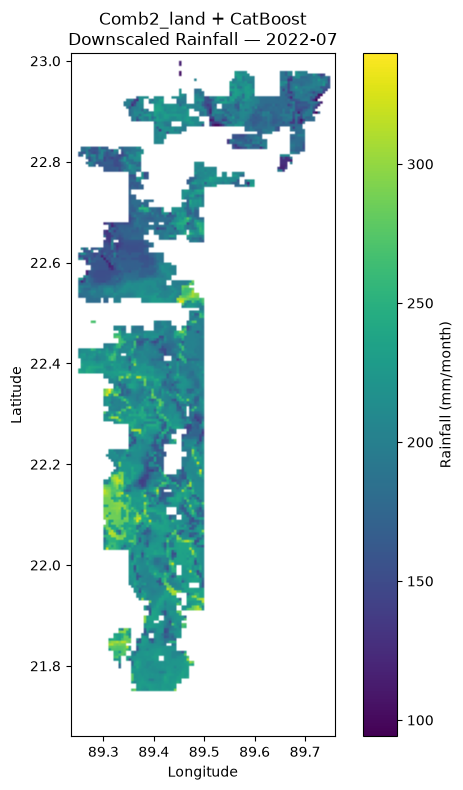

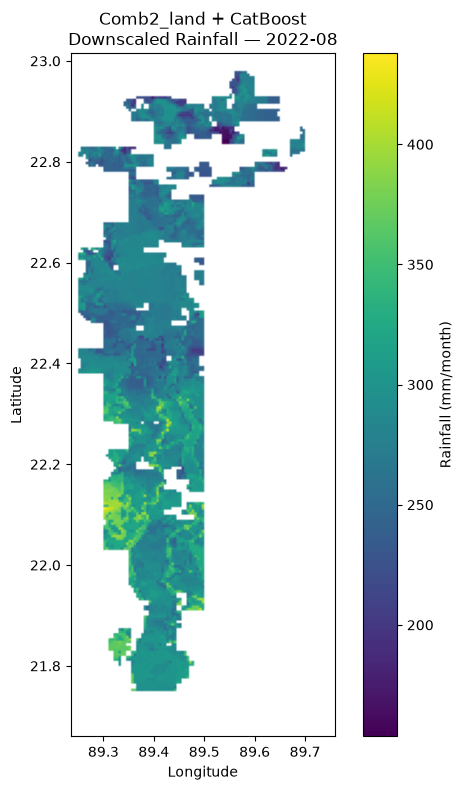

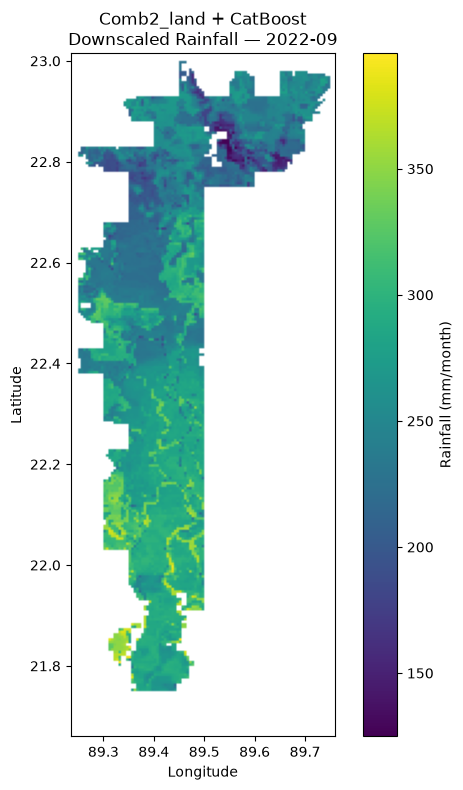

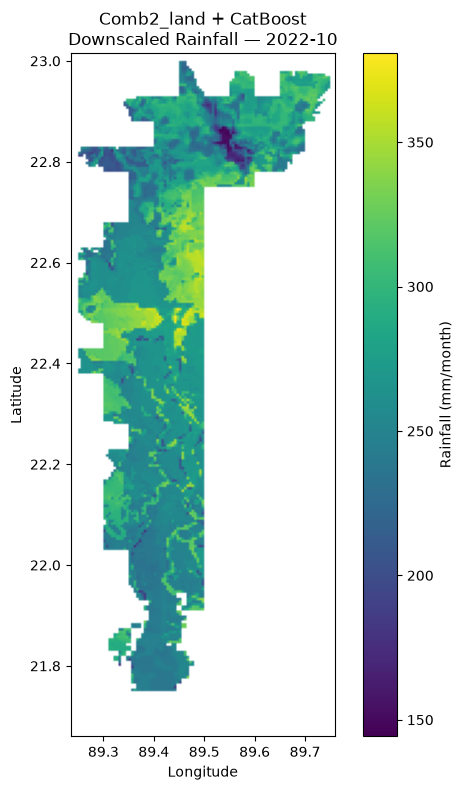

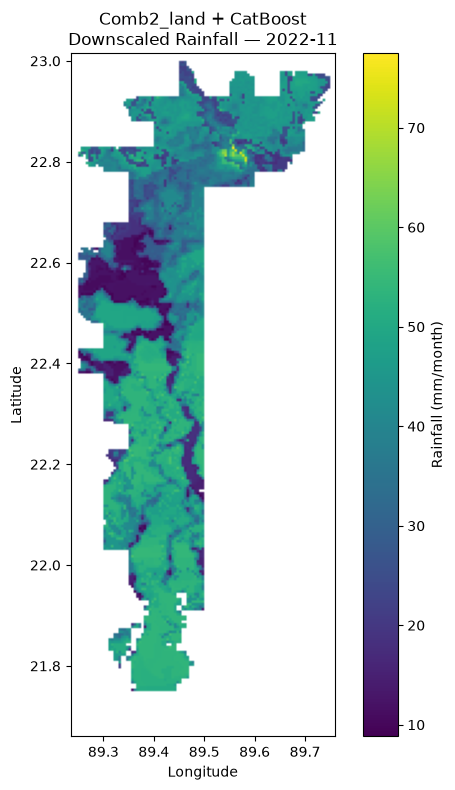

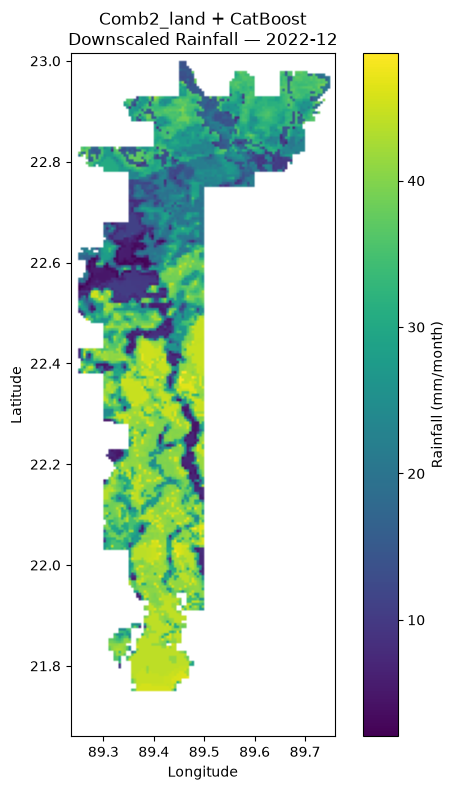

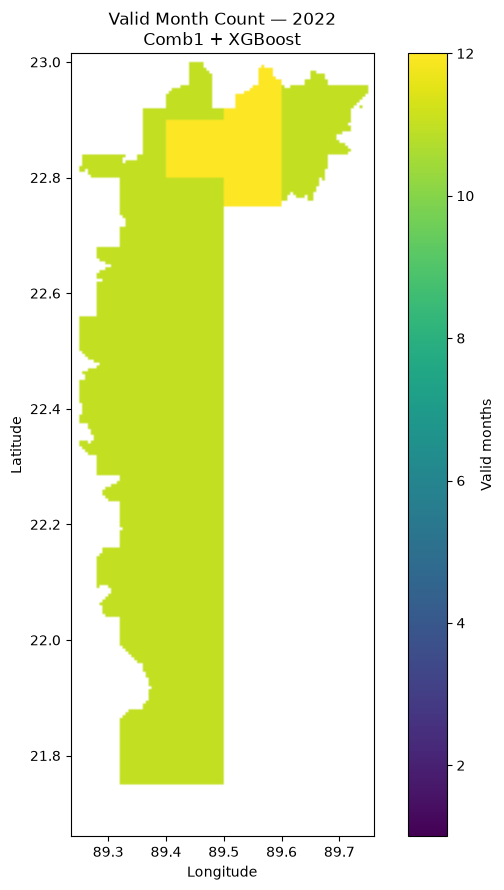

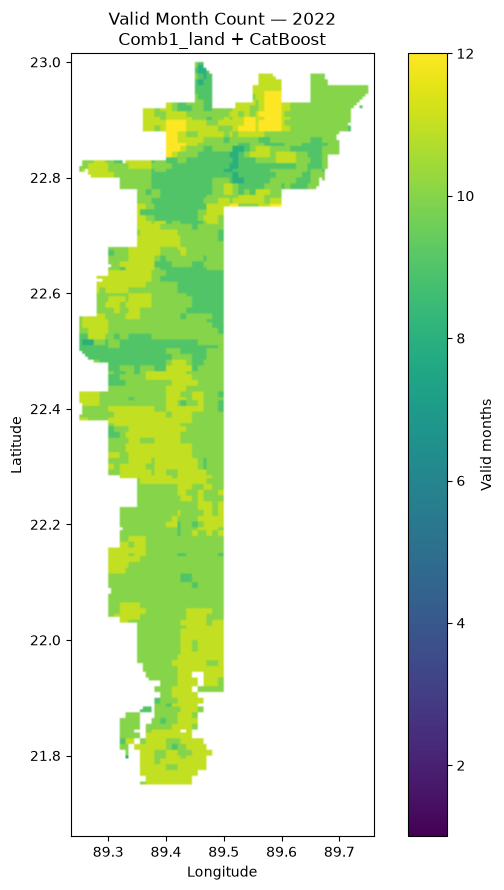

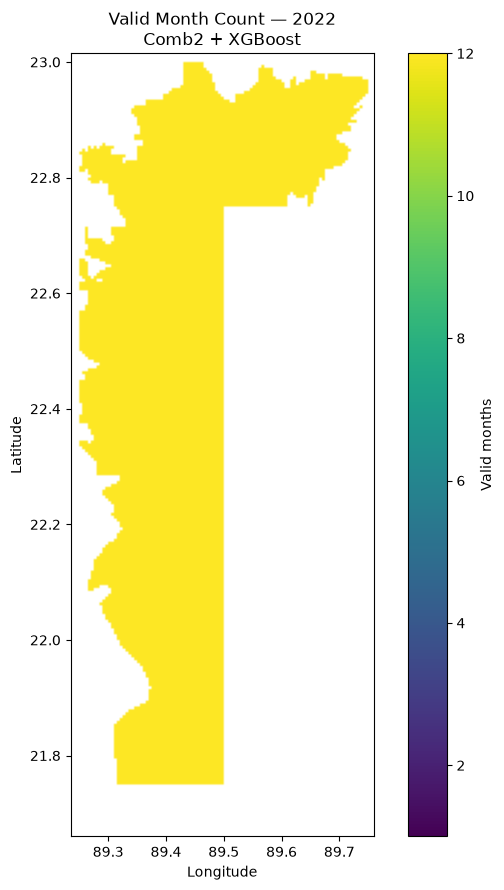

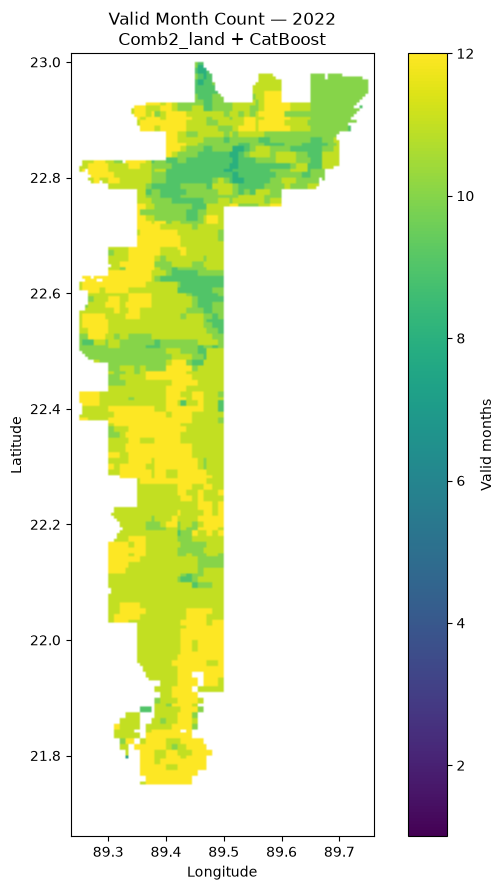

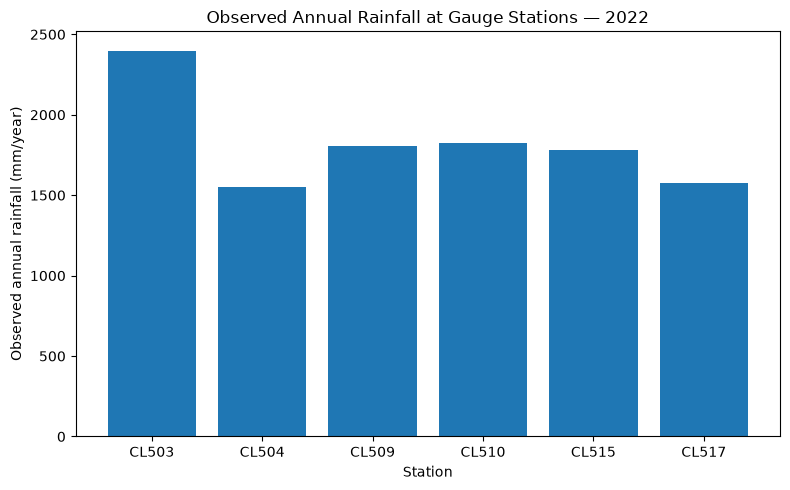


ALL IMPORTANT OUTPUTS DISPLAYED


In [15]:
# ============================================================
# 15. VISUALIZE ALL IMPORTANT OUTPUTS
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import rasterio


# ============================================================
# A. VALIDATION + TEST METRICS TABLE
# ============================================================

print("\n==========================================")
print("VALIDATION + TEST METRICS")
print("==========================================")

display(
    all_metrics[
        [
            "combination",
            "model",
            "valid_MAE",
            "valid_RMSE",
            "valid_PCC",
            "valid_R2",
            "test_MAE",
            "test_RMSE",
            "test_PCC",
            "test_R2",
        ]
    ]
)


# ============================================================
# B. SELECTED BEST MODEL PER COMBINATION
# ============================================================

print("\n==========================================")
print("SELECTED BEST MODEL PER COMBINATION")
print("==========================================")

display(
    selected[
        [
            "combination",
            "model",
            "valid_RMSE",
            "valid_MAE",
            "valid_PCC",
            "test_RMSE",
            "test_MAE",
            "test_PCC",
        ]
    ]
)


# ============================================================
# C. RMSE COMPARISON BAR CHART
# ============================================================

plot_df = all_metrics.copy()

labels = (
    plot_df["combination"]
    + " | "
    + plot_df["model"]
)

x = np.arange(
    len(plot_df)
)

width = 0.38

fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.bar(
    x - width/2,
    plot_df["valid_RMSE"],
    width,
    label="Validation RMSE"
)

ax.bar(
    x + width/2,
    plot_df["test_RMSE"],
    width,
    label="Test RMSE"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    labels,
    rotation=90
)

ax.set_ylabel(
    "RMSE (mm/month)"
)

ax.set_title(
    "Validation vs Test RMSE"
)

ax.legend()

fig.tight_layout()

plt.show()


# ============================================================
# D. MAE COMPARISON BAR CHART
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.bar(
    x - width/2,
    plot_df["valid_MAE"],
    width,
    label="Validation MAE"
)

ax.bar(
    x + width/2,
    plot_df["test_MAE"],
    width,
    label="Test MAE"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    labels,
    rotation=90
)

ax.set_ylabel(
    "MAE (mm/month)"
)

ax.set_title(
    "Validation vs Test MAE"
)

ax.legend()

fig.tight_layout()

plt.show()


# ============================================================
# E. PCC COMPARISON BAR CHART
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.bar(
    x - width/2,
    plot_df["valid_PCC"],
    width,
    label="Validation PCC"
)

ax.bar(
    x + width/2,
    plot_df["test_PCC"],
    width,
    label="Test PCC"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    labels,
    rotation=90
)

ax.set_ylabel(
    "PCC"
)

ax.set_title(
    "Validation vs Test PCC"
)

ax.legend()

fig.tight_layout()

plt.show()


# ============================================================
# F. BEST OVERALL SCATTER
# ============================================================

print("\n==========================================")
print("BEST OVERALL TEST SCATTER")
print("==========================================")

best_combo = best_overall["combination"]
best_model_name = best_overall["model"]

scatter_data = test_predictions[
    (test_predictions["combination"] == best_combo)
    &
    (test_predictions["model"] == best_model_name)
].copy()

fig, ax = plt.subplots(
    figsize=(6, 6)
)

ax.scatter(
    scatter_data["rainfall_mm"],
    scatter_data["predicted_mm"]
)

lo = min(
    scatter_data["rainfall_mm"].min(),
    scatter_data["predicted_mm"].min()
)

hi = max(
    scatter_data["rainfall_mm"].max(),
    scatter_data["predicted_mm"].max()
)

ax.plot(
    [lo, hi],
    [lo, hi],
    linestyle="--"
)

ax.set_xlabel(
    "Observed rainfall (mm/month)"
)

ax.set_ylabel(
    "Predicted rainfall (mm/month)"
)

ax.set_title(
    f"{best_combo} + {best_model_name}\n"
    f"Test RMSE={best_overall['test_RMSE']:.2f}, "
    f"MAE={best_overall['test_MAE']:.2f}, "
    f"PCC={best_overall['test_PCC']:.3f}"
)

fig.tight_layout()

plt.show()


# ============================================================
# G. TEST PREDICTIONS TABLE
# ============================================================

print("\n==========================================")
print("2022 STATION PREDICTIONS")
print("==========================================")

display(
    test_predictions[
        [
            "station_id",
            "month",
            "combination",
            "model",
            "rainfall_mm",
            "predicted_mm",
            "error_mm",
            "abs_error_mm",
        ]
    ]
)


# ============================================================
# H. MONTHLY SPATIAL QC TABLE
# ============================================================

print("\n==========================================")
print("MONTHLY SPATIAL QC")
print("==========================================")

display(
    spatial_qc
)


# ============================================================
# I. MONTHLY COVERAGE CHART
# ============================================================

for combo in spatial_qc["combination"].unique():

    d = spatial_qc[
        spatial_qc["combination"] == combo
    ]

    fig, ax = plt.subplots(
        figsize=(8, 4)
    )

    ax.plot(
        d["month"],
        d["coverage_pct_inside_khulna"],
        marker="o"
    )

    ax.set_xticks(
        range(1, 13)
    )

    ax.set_xlabel(
        "Month"
    )

    ax.set_ylabel(
        "Valid coverage inside Khulna (%)"
    )

    ax.set_title(
        f"Monthly Spatial Coverage — {combo}"
    )

    ax.grid(
        True,
        alpha=0.3
    )

    fig.tight_layout()

    plt.show()


# ============================================================
# J. ANNUAL SUMMARY TABLE
# ============================================================

print("\n==========================================")
print("ANNUAL 2022 SUMMARY")
print("==========================================")

display(
    annual_summary
)


# ============================================================
# K. ANNUAL RAINFALL MAPS
# ============================================================

for _, row in annual_summary.iterrows():

    tif_path = Path(
        row["annual_tif"]
    )

    if not tif_path.exists():
        continue

    with rasterio.open(
        tif_path
    ) as src:

        arr = src.read(
            1
        ).astype(
            float
        )

        nodata = src.nodata

        if nodata is not None:
            arr[
                np.isclose(
                    arr,
                    nodata
                )
            ] = np.nan

        extent = [
            src.bounds.left,
            src.bounds.right,
            src.bounds.bottom,
            src.bounds.top,
        ]


    fig, ax = plt.subplots(
        figsize=(7, 9)
    )

    im = ax.imshow(
        arr,
        extent=extent,
        origin="upper"
    )

    plt.colorbar(
        im,
        ax=ax,
        label="Annual rainfall (mm/year)"
    )

    ax.set_xlabel(
        "Longitude"
    )

    ax.set_ylabel(
        "Latitude"
    )

    ax.set_title(
        f"Annual Downscaled Rainfall 2022\n"
        f"{row['combination']} + {row['model']}"
    )

    fig.tight_layout()

    plt.show()


# ============================================================
# L. 12 MONTHLY MAPS FOR EACH SELECTED COMBINATION
# ============================================================

for _, row in selected.iterrows():

    combo = row["combination"]
    model_name = row["model"]

    print(
        "\n=========================================="
    )

    print(
        f"MONTHLY MAPS: {combo} + {model_name}"
    )

    print(
        "=========================================="
    )


    for month in range(
        1,
        13
    ):

        tif_path = (
            RUN_DIR
            / "maps"
            / combo
            / model_name
            / f"downscaled_2022_{month:02d}.tif"
        )

        if not tif_path.exists():
            print(
                "Missing:",
                tif_path
            )
            continue


        with rasterio.open(
            tif_path
        ) as src:

            arr = src.read(
                1
            ).astype(
                float
            )

            nodata = src.nodata

            if nodata is not None:

                arr[
                    np.isclose(
                        arr,
                        nodata
                    )
                ] = np.nan


            extent = [

                src.bounds.left,
                src.bounds.right,
                src.bounds.bottom,
                src.bounds.top

            ]


        fig, ax = plt.subplots(
            figsize=(6, 8)
        )

        im = ax.imshow(
            arr,
            extent=extent,
            origin="upper"
        )

        plt.colorbar(
            im,
            ax=ax,
            label="Rainfall (mm/month)"
        )

        ax.set_xlabel(
            "Longitude"
        )

        ax.set_ylabel(
            "Latitude"
        )

        ax.set_title(
            f"{combo} + {model_name}\n"
            f"Downscaled Rainfall — 2022-{month:02d}"
        )

        fig.tight_layout()

        plt.show()


# ============================================================
# M. VALID MONTH COUNT MAPS
# ============================================================

for _, row in annual_summary.iterrows():

    tif_path = Path(
        row[
            "valid_month_count_tif"
        ]
    )

    if not tif_path.exists():
        continue


    with rasterio.open(
        tif_path
    ) as src:

        arr = src.read(
            1
        ).astype(
            float
        )

        arr[
            arr == 0
        ] = np.nan

        extent = [

            src.bounds.left,
            src.bounds.right,
            src.bounds.bottom,
            src.bounds.top,

        ]


    fig, ax = plt.subplots(
        figsize=(7, 9)
    )

    im = ax.imshow(
        arr,
        extent=extent,
        origin="upper",
        vmin=1,
        vmax=12
    )

    plt.colorbar(
        im,
        ax=ax,
        label="Valid months"
    )

    ax.set_xlabel(
        "Longitude"
    )

    ax.set_ylabel(
        "Latitude"
    )

    ax.set_title(
        f"Valid Month Count — 2022\n"
        f"{row['combination']} + {row['model']}"
    )

    fig.tight_layout()

    plt.show()


# ============================================================
# N. OBSERVED ANNUAL GAUGE BAR CHART
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    observed_2022["station_id"],
    observed_2022["observed_annual_mm"]
)

ax.set_xlabel(
    "Station"
)

ax.set_ylabel(
    "Observed annual rainfall (mm/year)"
)

ax.set_title(
    "Observed Annual Rainfall at Gauge Stations — 2022"
)

fig.tight_layout()

plt.show()


# ============================================================
# O. FINAL MESSAGE
# ============================================================

print(
    "\n=========================================="
)

print(
    "ALL IMPORTANT OUTPUTS DISPLAYED"
)

print(
    "=========================================="
)